# Imports

In [1]:
import os


os.chdir("../")

In [2]:
from utils import (hyperas_path, init, load_cifar10, get_model, 
                get_callbacks, plot_history, extract_features, 
                show_img, continually_learn, save_samples, 
                load_samples, CL_plot)


TUNED_CNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_cnn_model_01.h5")
TUNED_DNN_MODEL_PATH = os.path.join(hyperas_path, "cifar10_dnn_model_00.h5")

CLASS_NUM = 10
BATCH_SIZE = 128
EPOCHS = 100

init()

# Demonstrating the usual 10-class training setting

## Hyperparameter-tuned CNN Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10()

(40000, 32, 32, 3) (40000, 1)
(10000, 32, 32, 3) (10000, 1)
(10000, 32, 32, 3) (10000, 1)
---0
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---1
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]

---2
0 [0.1]
1 [0.1]
2 [0.1]
3 [0.1]
4 [0.1]
5 [0.1]
6 [0.1]
7 [0.1]
8 [0.1]
9 [0.1]



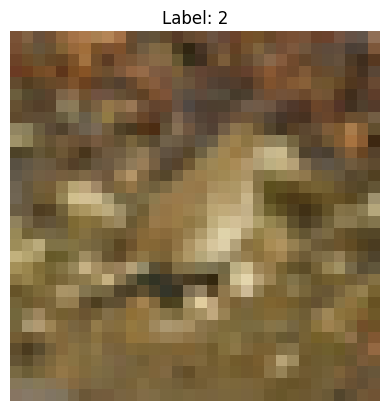

In [12]:
index = 1_000
show_img(x_train[index], y_train[index])

In [13]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_CNN_MODEL_PATH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_6 (Sequential)   (None, 16, 16, 64)        9664      
                                                                 
 sequential_7 (Sequential)   (None, 8, 8, 128)         222208    
                                                                 
 sequential_8 (Sequential)   (None, 4, 4, 128)         295936    
                                                                 
 sequential_9 (Sequential)   (None, 2, 2, 256)         295936    
                                                                 
 global_average_pooling2d_1   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                        

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 11s 23ms/step - loss: 1.4033 - accuracy: 0.4966 - val_loss: 2.6316 - val_accuracy: 0.2719
Epoch 2/100
313/313 [==============================] - 7s 21ms/step - loss: 0.9531 - accuracy: 0.6611 - val_loss: 1.5426 - val_accuracy: 0.5000
Epoch 3/100
313/313 [==============================] - 7s 21ms/step - loss: 0.7570 - accuracy: 0.7338 - val_loss: 1.0097 - val_accuracy: 0.6537
Epoch 4/100
313/313 [==============================] - 7s 21ms/step - loss: 0.6215 - accuracy: 0.7837 - val_loss: 0.9815 - val_accuracy: 0.6718
Epoch 5/100
313/313 [==============================] - 7s 21ms/step - loss: 0.5252 - accuracy: 0.8175 - val_loss: 0.9472 - val_accuracy: 0.6873
Epoch 6/100
313/313 [==============================] - 7s 21ms/step - loss: 0.4368 - accuracy: 0.8478 - val_loss: 0.9513 - val_accuracy: 0.6909
Epoch 7/100
313/313 [==============================] - 7s 21ms/step - loss: 0.3714 - accuracy: 0.8706 - val_loss: 1.0242 - val_accuracy

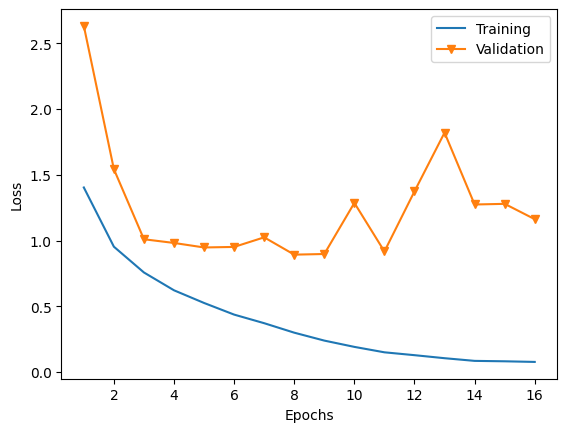

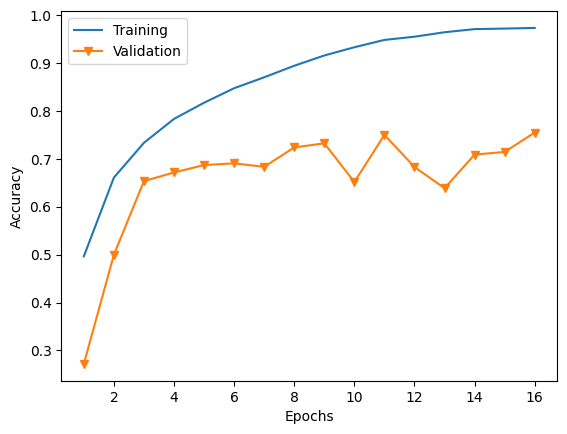

313/313 [==============================] - 1s 4ms/step - loss: 0.9191 - accuracy: 0.7528


[0.9191192388534546, 0.7527999877929688]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

## Hyperparameter-tuned DNN Model

In [3]:
feature_train, y_train, feature_val, y_val, feature_test, y_test = load_cifar10(return_features=True)

In [4]:
model = get_model(CLASS_NUM, model_type="hp-tuned", model_path=TUNED_DNN_MODEL_PATH)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_353 (Ba  (None, 2048)             8192      
 tchNormalization)                                               
                                                                 
 sequential_336 (Sequential)  (None, 256)              525312    
                                                                 
 sequential_337 (Sequential)  (None, 128)              33280     
                                                                 
 dropout_488 (Dropout)       (None, 128)               0         
                                                                 
 dense (Dense)               (None, 10)                1290      
                                                                 
Total params: 568,074
Trainable params: 563,210
Non-trainable params: 4,864
______________________________________________

In [5]:
history = model.fit(
    feature_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 4s 9ms/step - loss: 0.5236 - accuracy: 0.8299 - val_loss: 0.3807 - val_accuracy: 0.8702
Epoch 2/100
313/313 [==============================] - 3s 8ms/step - loss: 0.3576 - accuracy: 0.8787 - val_loss: 0.3280 - val_accuracy: 0.8882
Epoch 3/100
313/313 [==============================] - 3s 9ms/step - loss: 0.3113 - accuracy: 0.8926 - val_loss: 0.3211 - val_accuracy: 0.8878
Epoch 4/100
313/313 [==============================] - 3s 8ms/step - loss: 0.2811 - accuracy: 0.9026 - val_loss: 0.3181 - val_accuracy: 0.8899
Epoch 5/100
313/313 [==============================] - 2s 8ms/step - loss: 0.2555 - accuracy: 0.9121 - val_loss: 0.3176 - val_accuracy: 0.8935
Epoch 6/100
313/313 [==============================] - 3s 8ms/step - loss: 0.2357 - accuracy: 0.9183 - val_loss: 0.3181 - val_accuracy: 0.8958
Epoch 7/100
313/313 [==============================] - 3s 8ms/step - loss: 0.2226 - accuracy: 0.9214 - val_loss: 0.3235 - val_accuracy: 0.8954

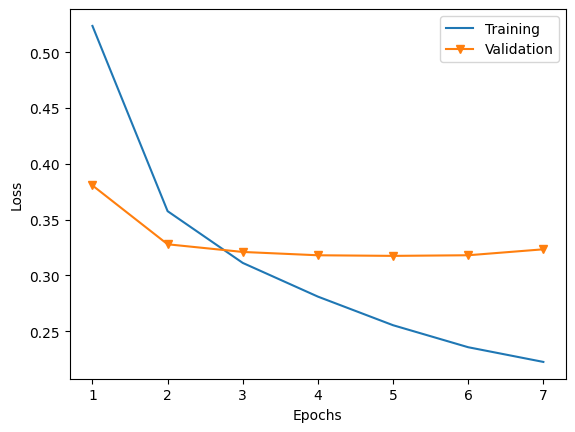

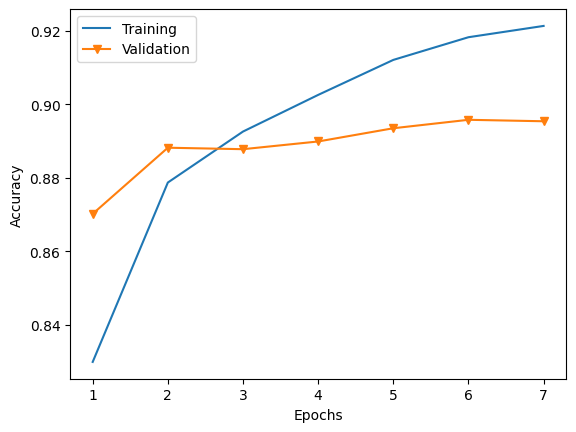

313/313 [==============================] - 1s 4ms/step - loss: 0.3295 - accuracy: 0.8887


[0.32947906851768494, 0.888700008392334]

In [6]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Transfer Learning with the pre-trained Xception Model

In [11]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess=False, verbose=0)

In [12]:
feature_train, feature_val, feature_test = extract_features(
    [x_train, x_val, x_test], 
    batch_size=BATCH_SIZE, 
    file_name="./data/cifar10_xception_gavgpooled_features_train_val_test"
)

79/79 [==============================] - 73s 940ms/step


In [ ]:
feature_train, feature_val, feature_test = load_samples(
    "./data/cifar10_xception_gavgpooled_features_train_val_test", 
    ".npy"
)

In [13]:
model = get_model(CLASS_NUM, model_type="DNN", dropout_rate=0.5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 dense_1 (Dense)             (None, 10)                20490     
                                                                 
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
_________________________________________________________________


In [14]:
history = model.fit(
    feature_train, y_train,
    epochs=EPOCHS,
    validation_data=(feature_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
1250/1250 [==============================] - 5s 3ms/step - loss: 0.5361 - accuracy: 0.8285 - val_loss: 0.3863 - val_accuracy: 0.8721
Epoch 2/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3932 - accuracy: 0.8654 - val_loss: 0.3503 - val_accuracy: 0.8823
Epoch 3/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3732 - accuracy: 0.8723 - val_loss: 0.3413 - val_accuracy: 0.8801
Epoch 4/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3636 - accuracy: 0.8747 - val_loss: 0.3416 - val_accuracy: 0.8793
Epoch 5/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3554 - accuracy: 0.8781 - val_loss: 0.3305 - val_accuracy: 0.8827
Epoch 6/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3528 - accuracy: 0.8779 - val_loss: 0.3327 - val_accuracy: 0.8833
Epoch 7/100
1250/1250 [==============================] - 4s 3ms/step - loss: 0.3501 - accuracy: 0.8789 - val_loss: 0.3277 - val_ac

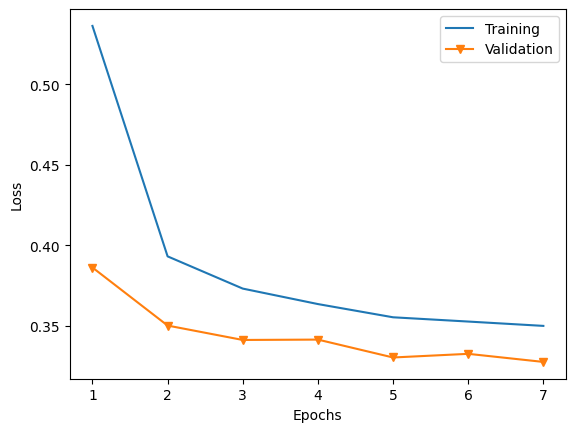

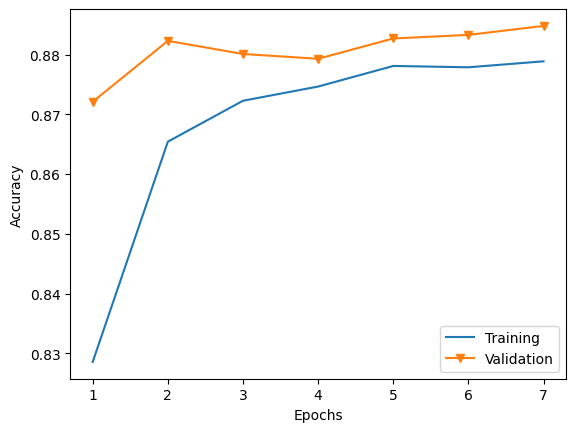

313/313 [==============================] - 1s 3ms/step - loss: 0.3587 - accuracy: 0.8788


[0.35869887471199036, 0.8787999749183655]

In [15]:
plot_history(history)

model.evaluate(feature_test, y_test)

## Fine-tuning the pre-trained Xception Model

In [9]:
x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10(preprocess=False, verbose=0)

In [12]:
model = get_model(CLASS_NUM, model_type="pretrained", num_last_not_frozen=12, dropout_rate=0.50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resize (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 xception_preprocess (Lambda  (None, 299, 299, 3)      0         
 )                                                               
                                                                 
 xception (Functional)       (None, 10, 10, 2048)      20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 10)                2

In [13]:
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
).history

Epoch 1/100
313/313 [==============================] - 804s 3s/step - loss: 0.3157 - accuracy: 0.8951 - val_loss: 0.2794 - val_accuracy: 0.9133
Epoch 2/100
313/313 [==============================] - 833s 3s/step - loss: 0.1676 - accuracy: 0.9423 - val_loss: 0.2581 - val_accuracy: 0.9157
Epoch 3/100
313/313 [==============================] - 666s 2s/step - loss: 0.1059 - accuracy: 0.9624 - val_loss: 0.2893 - val_accuracy: 0.9163
Epoch 4/100
313/313 [==============================] - 495s 2s/step - loss: 0.0650 - accuracy: 0.9777 - val_loss: 0.3214 - val_accuracy: 0.9159
Epoch 5/100
313/313 [==============================] - 828s 3s/step - loss: 0.0417 - accuracy: 0.9857 - val_loss: 0.2883 - val_accuracy: 0.9222
Epoch 6/100
313/313 [==============================] - 871s 3s/step - loss: 0.0360 - accuracy: 0.9877 - val_loss: 0.3195 - val_accuracy: 0.9259
Epoch 7/100
313/313 [==============================] - 681s 2s/step - loss: 0.0318 - accuracy: 0.9886 - val_loss: 0.3426 - val_accuracy:

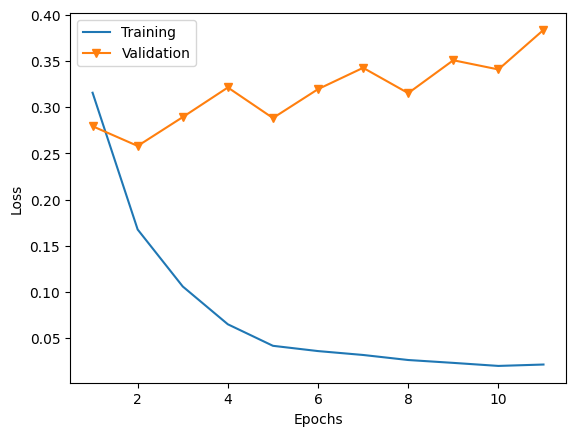

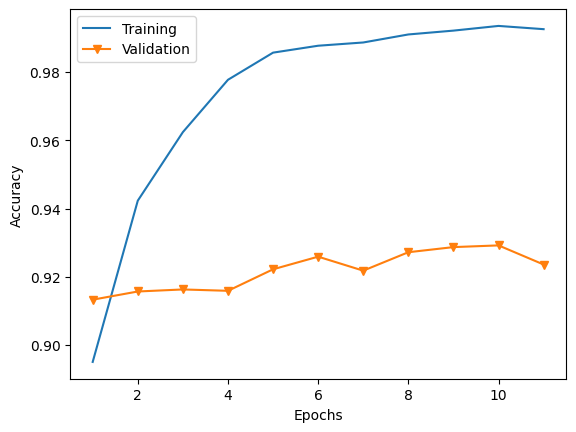

313/313 [==============================] - 159s 488ms/step - loss: 0.3389 - accuracy: 0.9225


[0.338937371969223, 0.9225000143051147]

In [14]:
plot_history(history)

model.evaluate(x_test, y_test)

# Continual Learning

## Continually adding classes to different models

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


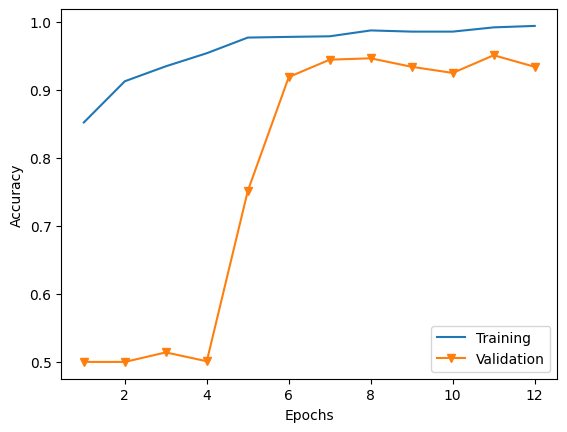

63/63 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0     0.9600    0.9350    0.9473      1000
           1     0.9366    0.9610    0.9487      1000

    accuracy                         0.9480      2000
   macro avg     0.9483    0.9480    0.9480      2000
weighted avg     0.9483    0.9480    0.9480      2000



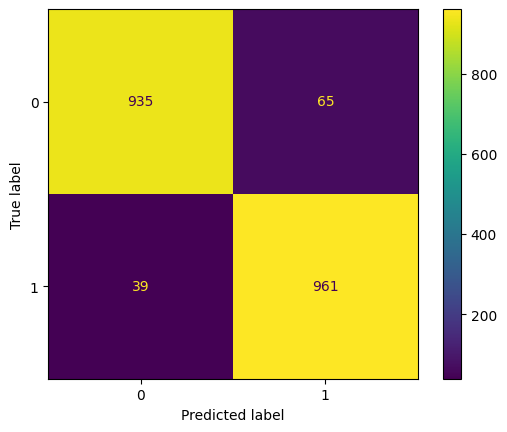

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


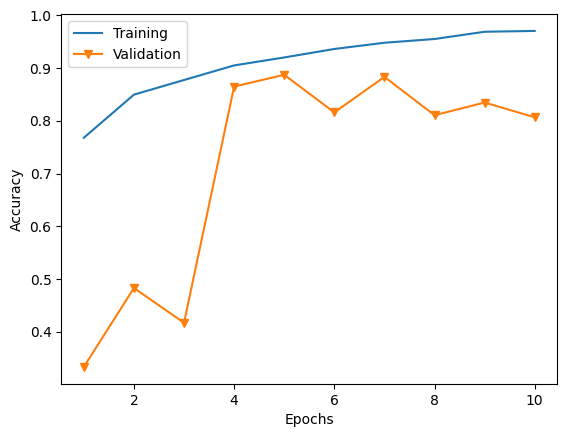

94/94 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0     0.8975    0.8140    0.8537      1000
           1     0.9553    0.9180    0.9363      1000
           2     0.8242    0.9330    0.8752      1000

    accuracy                         0.8883      3000
   macro avg     0.8923    0.8883    0.8884      3000
weighted avg     0.8923    0.8883    0.8884      3000



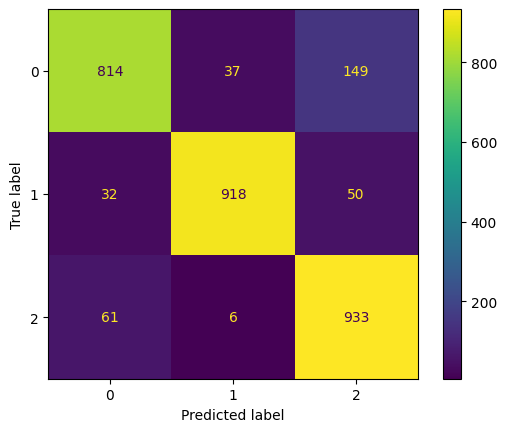

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 7.
Epoch 12: early stopping


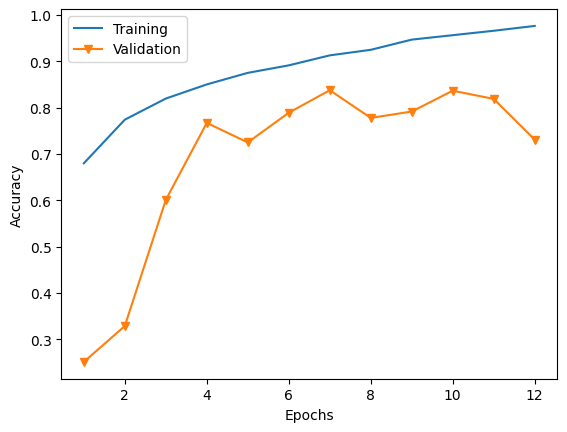

125/125 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7579    0.9390    0.8388      1000
           1     0.9708    0.8970    0.9324      1000
           2     0.8311    0.6940    0.7564      1000
           3     0.7944    0.7960    0.7952      1000

    accuracy                         0.8315      4000
   macro avg     0.8385    0.8315    0.8307      4000
weighted avg     0.8385    0.8315    0.8307      4000



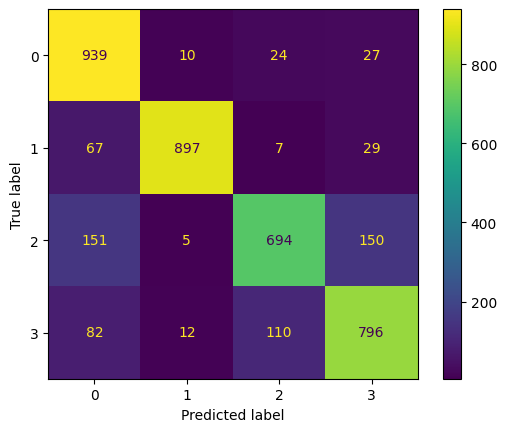

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


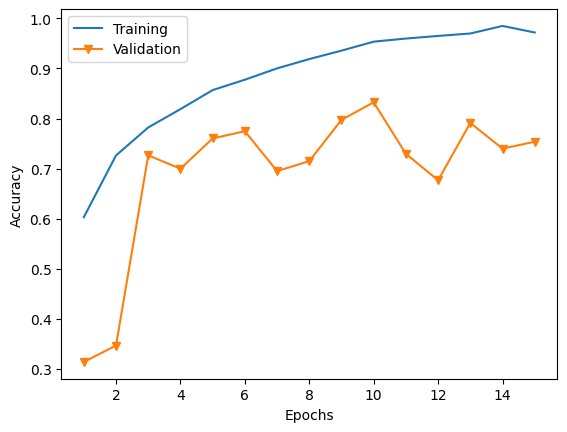

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8027    0.9070    0.8516      1000
           1     0.9284    0.9590    0.9434      1000
           2     0.8734    0.6140    0.7211      1000
           3     0.7412    0.8220    0.7795      1000
           4     0.8039    0.8240    0.8138      1000

    accuracy                         0.8252      5000
   macro avg     0.8299    0.8252    0.8219      5000
weighted avg     0.8299    0.8252    0.8219      5000



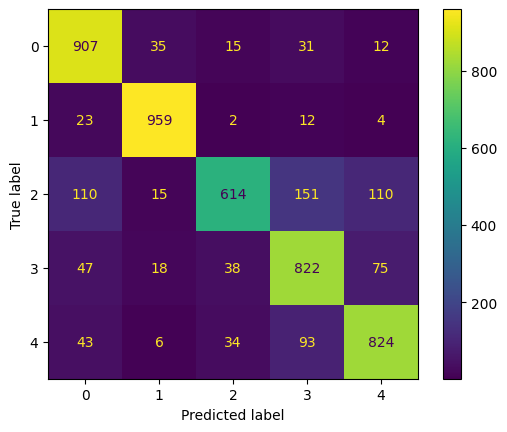

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 10.
Epoch 15: early stopping


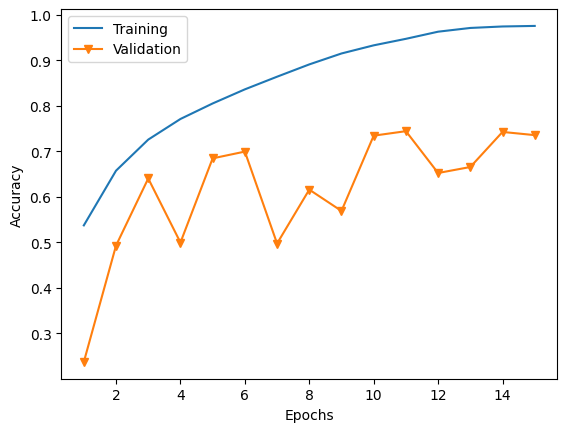

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.6401    0.9090    0.7512      1000
           1     0.8383    0.9750    0.9015      1000
           2     0.7381    0.5270    0.6149      1000
           3     0.5845    0.6400    0.6110      1000
           4     0.8390    0.6620    0.7401      1000
           5     0.7497    0.6140    0.6751      1000

    accuracy                         0.7212      6000
   macro avg     0.7316    0.7212    0.7156      6000
weighted avg     0.7316    0.7212    0.7156      6000



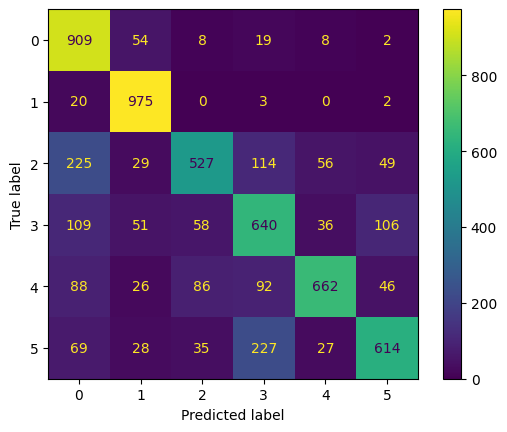

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 18.
Epoch 23: early stopping


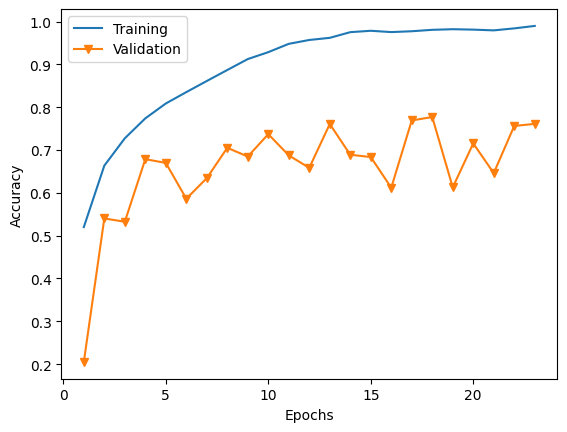

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8636    0.8230    0.8428      1000
           1     0.9859    0.8420    0.9083      1000
           2     0.8253    0.6330    0.7165      1000
           3     0.5283    0.8110    0.6398      1000
           4     0.7039    0.8560    0.7726      1000
           5     0.8563    0.5720    0.6859      1000
           6     0.8332    0.8390    0.8361      1000

    accuracy                         0.7680      7000
   macro avg     0.7995    0.7680    0.7717      7000
weighted avg     0.7995    0.7680    0.7717      7000



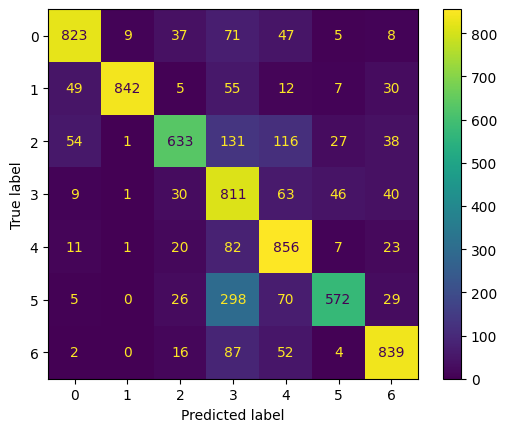

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


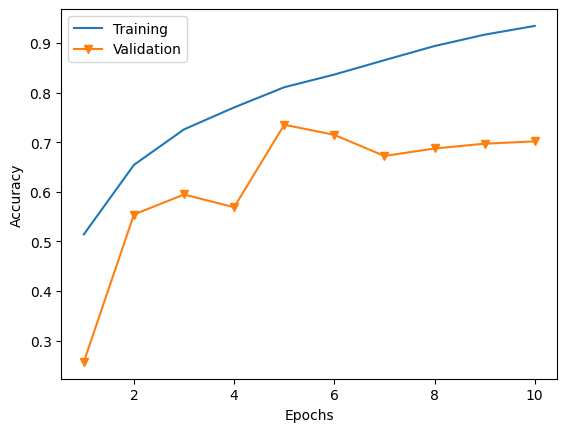

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8532    0.8310    0.8419      1000
           1     0.9471    0.9130    0.9297      1000
           2     0.7018    0.6000    0.6469      1000
           3     0.5492    0.6810    0.6080      1000
           4     0.8465    0.5130    0.6389      1000
           5     0.6618    0.5910    0.6244      1000
           6     0.6140    0.9210    0.7368      1000
           7     0.8285    0.8020    0.8150      1000

    accuracy                         0.7315      8000
   macro avg     0.7503    0.7315    0.7302      8000
weighted avg     0.7503    0.7315    0.7302      8000



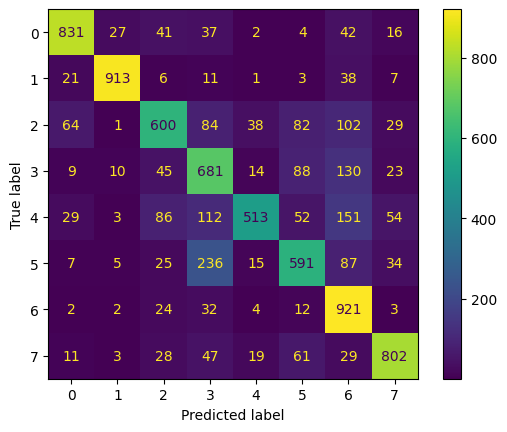

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 8.
Epoch 13: early stopping


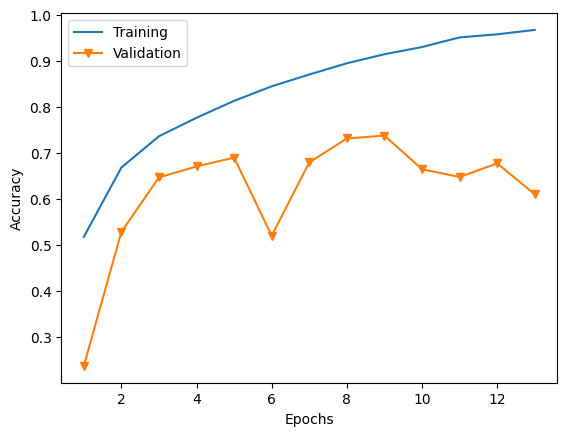

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.9548    0.5920    0.7309      1000
           1     0.8664    0.9400    0.9017      1000
           2     0.8947    0.3230    0.4747      1000
           3     0.5070    0.7260    0.5970      1000
           4     0.6862    0.7500    0.7167      1000
           5     0.6186    0.6780    0.6469      1000
           6     0.7222    0.8580    0.7843      1000
           7     0.8471    0.7980    0.8218      1000
           8     0.7811    0.9240    0.8465      1000

    accuracy                         0.7321      9000
   macro avg     0.7642    0.7321    0.7245      9000
weighted avg     0.7642    0.7321    0.7245      9000



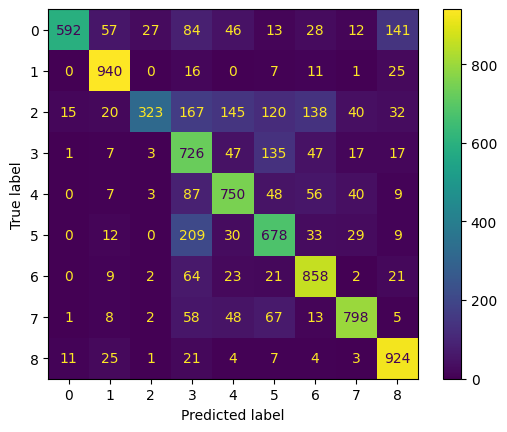

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 11.
Epoch 16: early stopping


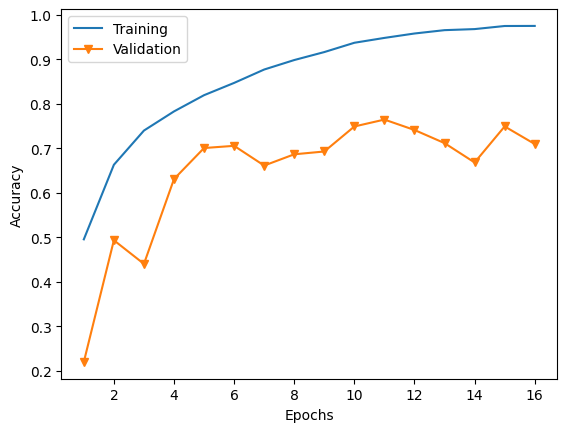

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8647    0.7220    0.7869      1000
           1     0.8609    0.8910    0.8757      1000
           2     0.7133    0.6940    0.7035      1000
           3     0.5809    0.6030    0.5918      1000
           4     0.7763    0.7080    0.7406      1000
           5     0.6724    0.6630    0.6677      1000
           6     0.7780    0.8340    0.8050      1000
           7     0.6903    0.8760    0.7721      1000
           8     0.7744    0.9270    0.8439      1000
           9     0.9531    0.6510    0.7736      1000

    accuracy                         0.7569     10000
   macro avg     0.7664    0.7569    0.7561     10000
weighted avg     0.7664    0.7569    0.7561     10000



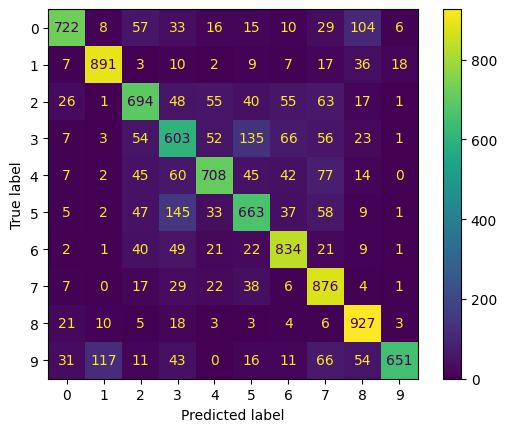

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


---------------------------------------------------------------------------



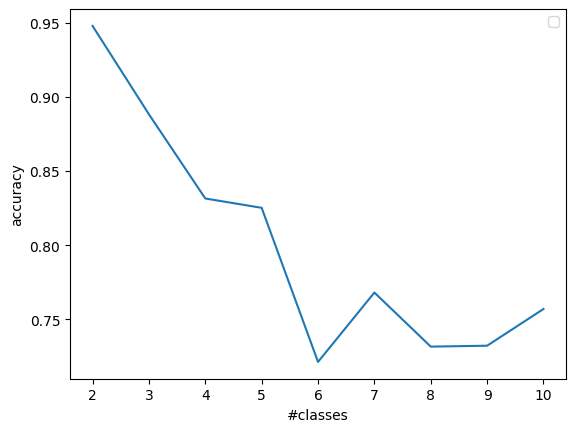

In [3]:
acc_list1 = continually_learn(
    CLASS_NUM, 
    load_cifar10, 
    False,
    False, 
    TUNED_CNN_MODEL_PATH, 
    BATCH_SIZE, 
    EPOCHS
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


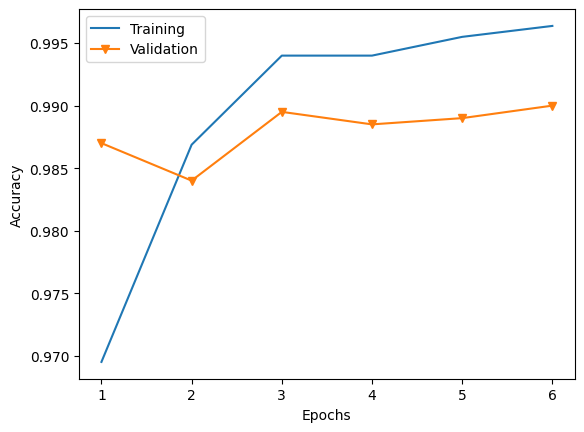

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9909    0.9850    0.9880      1000
           1     0.9851    0.9910    0.9880      1000

    accuracy                         0.9880      2000
   macro avg     0.9880    0.9880    0.9880      2000
weighted avg     0.9880    0.9880    0.9880      2000



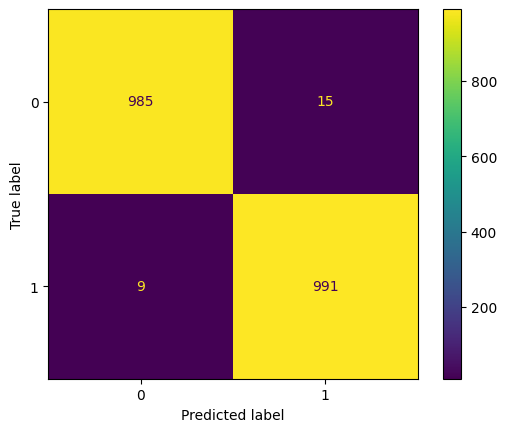

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


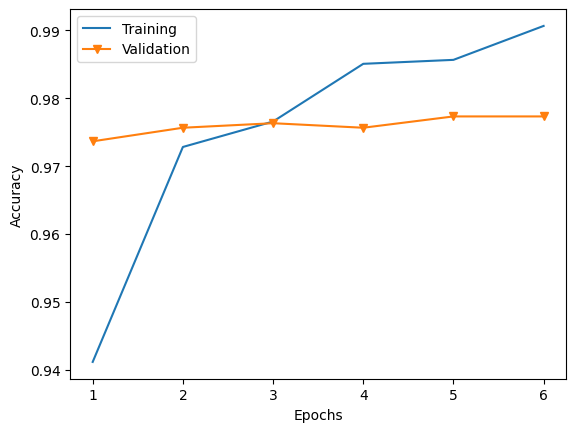

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9377    0.9790    0.9579      1000
           1     0.9870    0.9900    0.9885      1000
           2     0.9906    0.9440    0.9667      1000

    accuracy                         0.9710      3000
   macro avg     0.9718    0.9710    0.9711      3000
weighted avg     0.9718    0.9710    0.9711      3000



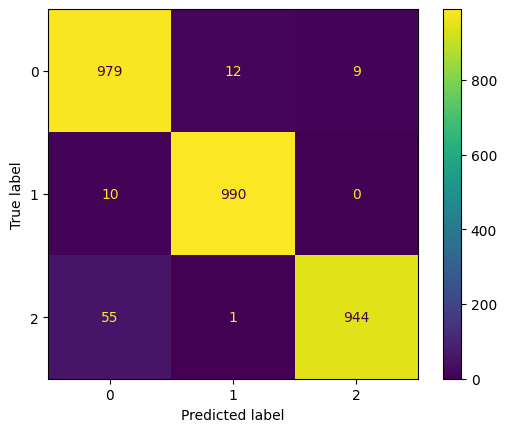

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


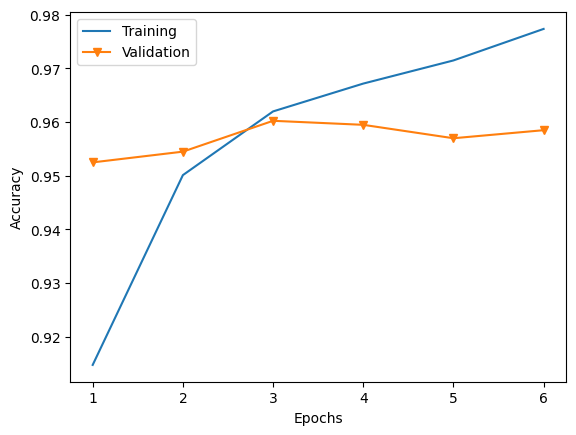

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9491    0.9500    0.9495      1000
           1     0.9888    0.9740    0.9814      1000
           2     0.9381    0.9090    0.9233      1000
           3     0.9120    0.9530    0.9320      1000

    accuracy                         0.9465      4000
   macro avg     0.9470    0.9465    0.9466      4000
weighted avg     0.9470    0.9465    0.9466      4000



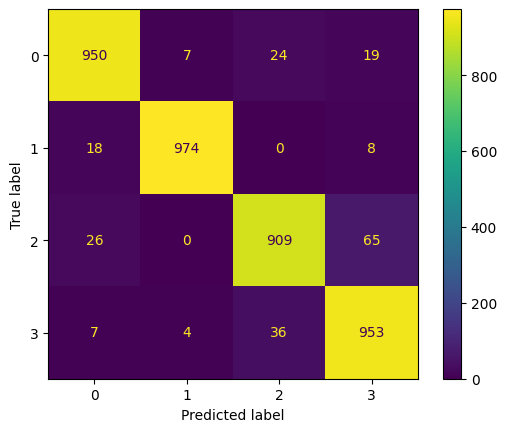

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


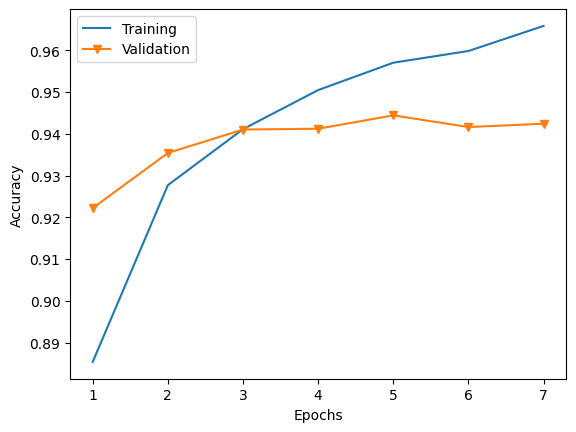

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9557    0.9490    0.9523      1000
           1     0.9908    0.9690    0.9798      1000
           2     0.9293    0.8670    0.8971      1000
           3     0.8723    0.9360    0.9030      1000
           4     0.9110    0.9320    0.9214      1000

    accuracy                         0.9306      5000
   macro avg     0.9318    0.9306    0.9307      5000
weighted avg     0.9318    0.9306    0.9307      5000



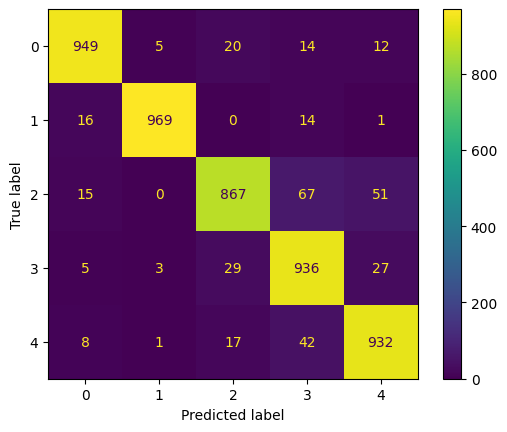

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


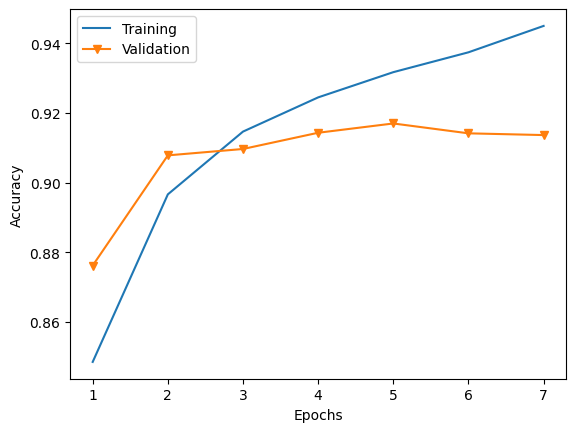

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9632    0.9410    0.9519      1000
           1     0.9849    0.9810    0.9830      1000
           2     0.8970    0.8710    0.8838      1000
           3     0.7950    0.8530    0.8230      1000
           4     0.8783    0.9310    0.9039      1000
           5     0.9025    0.8330    0.8664      1000

    accuracy                         0.9017      6000
   macro avg     0.9035    0.9017    0.9020      6000
weighted avg     0.9035    0.9017    0.9020      6000



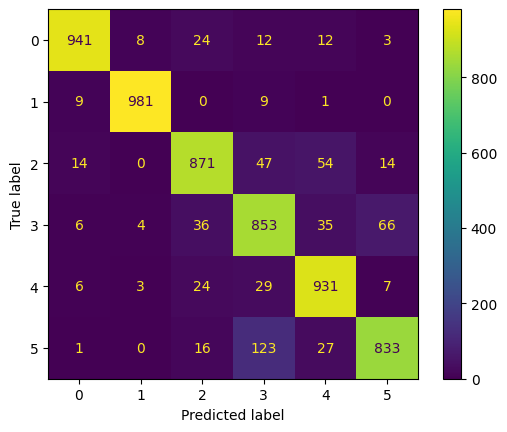

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


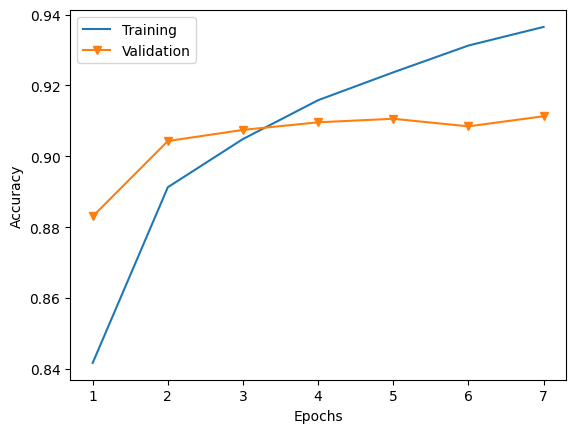

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9364    0.9570    0.9466      1000
           1     0.9879    0.9760    0.9819      1000
           2     0.9107    0.8260    0.8663      1000
           3     0.7534    0.8370    0.7930      1000
           4     0.8924    0.9120    0.9021      1000
           5     0.8854    0.8340    0.8589      1000
           6     0.9038    0.9110    0.9074      1000

    accuracy                         0.8933      7000
   macro avg     0.8957    0.8933    0.8937      7000
weighted avg     0.8957    0.8933    0.8937      7000



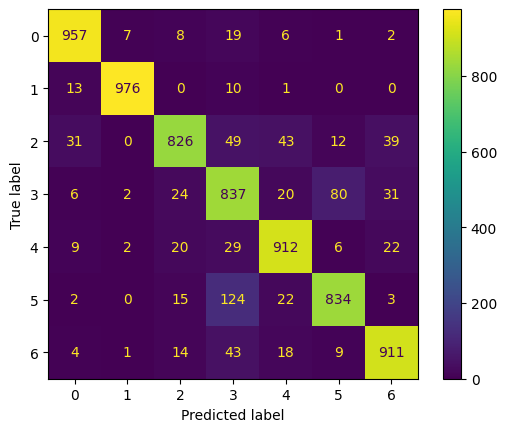

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


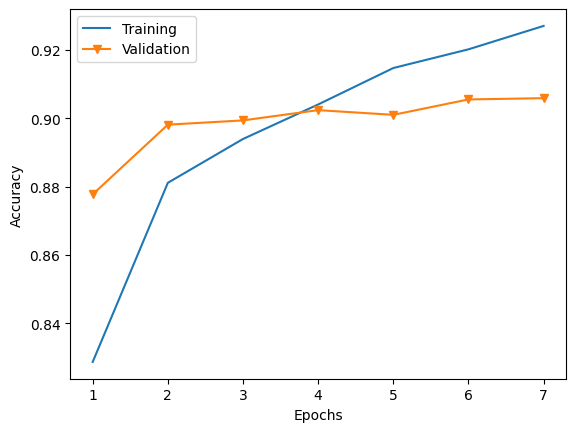

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9540    0.9120    0.9325      1000
           1     0.9714    0.9860    0.9787      1000
           2     0.8826    0.8420    0.8618      1000
           3     0.7658    0.8010    0.7830      1000
           4     0.8523    0.9000    0.8755      1000
           5     0.8573    0.8410    0.8491      1000
           6     0.8969    0.8960    0.8964      1000
           7     0.9204    0.9140    0.9172      1000

    accuracy                         0.8865      8000
   macro avg     0.8876    0.8865    0.8868      8000
weighted avg     0.8876    0.8865    0.8868      8000



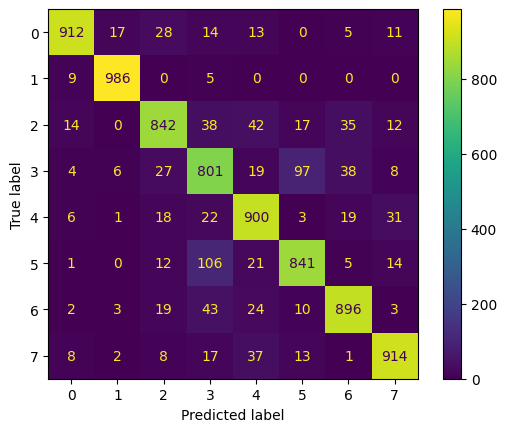

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


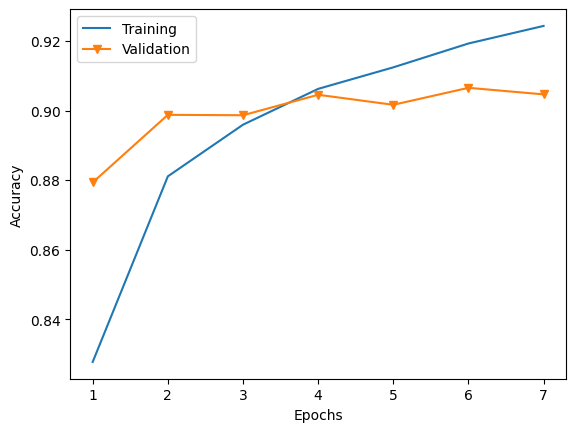

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8911    0.9160    0.9034      1000
           1     0.9768    0.9690    0.9729      1000
           2     0.8833    0.8630    0.8730      1000
           3     0.7814    0.8080    0.7945      1000
           4     0.8777    0.8680    0.8728      1000
           5     0.8582    0.8470    0.8525      1000
           6     0.8876    0.9080    0.8977      1000
           7     0.9040    0.9040    0.9040      1000
           8     0.9505    0.9220    0.9360      1000

    accuracy                         0.8894      9000
   macro avg     0.8901    0.8894    0.8896      9000
weighted avg     0.8901    0.8894    0.8896      9000



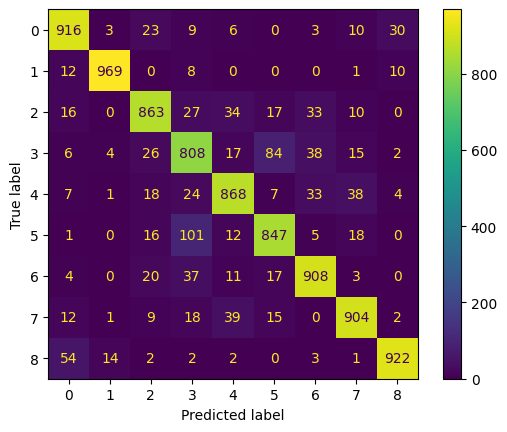

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


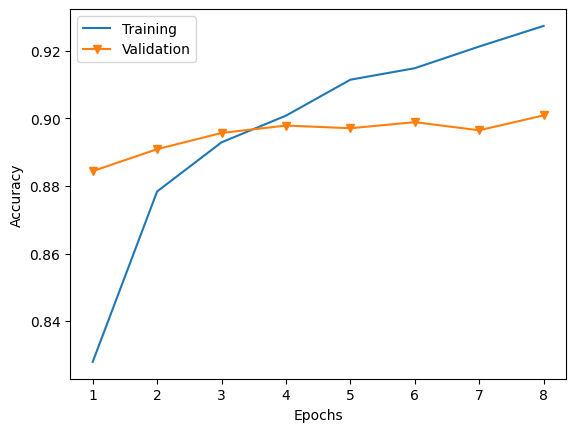

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8981    0.9080    0.9030      1000
           1     0.9352    0.9380    0.9366      1000
           2     0.8956    0.8490    0.8717      1000
           3     0.7878    0.8020    0.7948      1000
           4     0.8457    0.8880    0.8663      1000
           5     0.8663    0.8360    0.8509      1000
           6     0.8964    0.9170    0.9066      1000
           7     0.9198    0.8950    0.9072      1000
           8     0.9225    0.9410    0.9317      1000
           9     0.9272    0.9170    0.9221      1000

    accuracy                         0.8891     10000
   macro avg     0.8895    0.8891    0.8891     10000
weighted avg     0.8895    0.8891    0.8891     10000



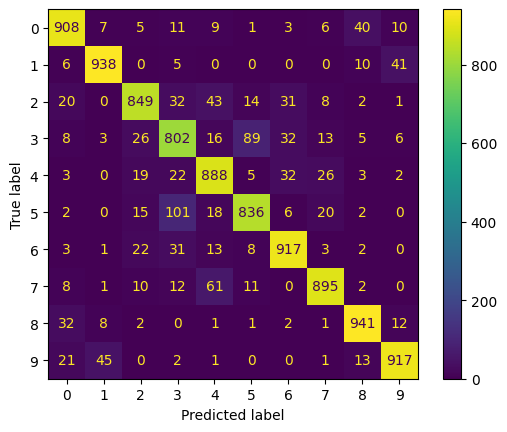

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


---------------------------------------------------------------------------



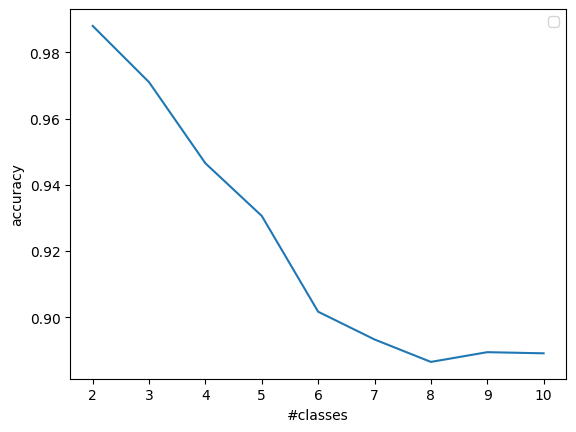

In [4]:
acc_list2 = continually_learn(
    CLASS_NUM, 
    load_cifar10, 
    False,
    False, 
    TUNED_DNN_MODEL_PATH, 
    BATCH_SIZE, 
    EPOCHS
)

## Continually adding classes to the same model

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 13.
Epoch 18: early stopping


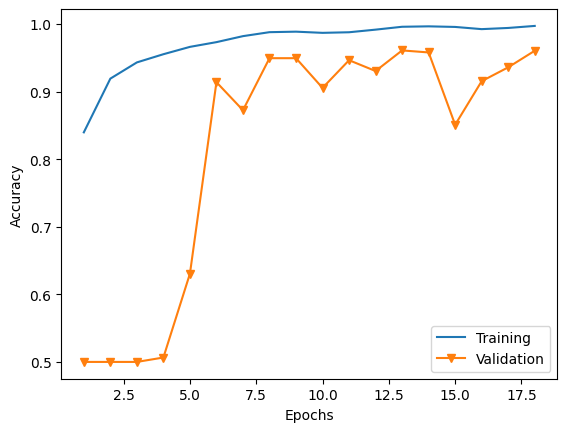

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9591    0.9620    0.9606      1000
           1     0.9619    0.9590    0.9604      1000

    accuracy                         0.9605      2000
   macro avg     0.9605    0.9605    0.9605      2000
weighted avg     0.9605    0.9605    0.9605      2000



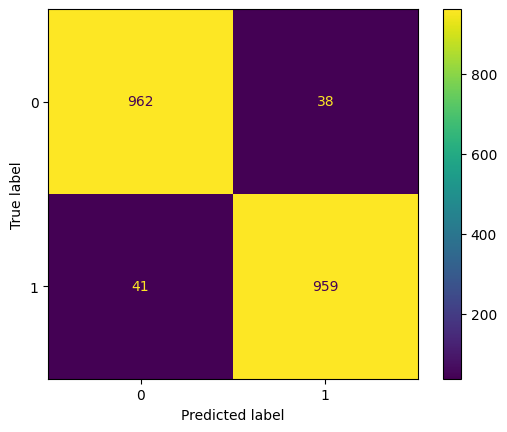

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


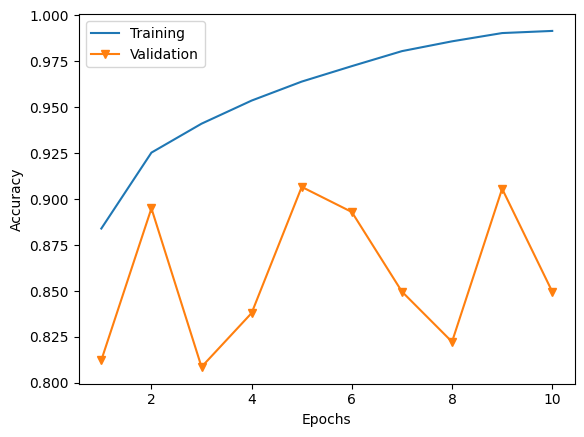

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8512    0.9270    0.8875      1000
           1     0.9461    0.9650    0.9554      1000
           2     0.9383    0.8360    0.8842      1000

    accuracy                         0.9093      3000
   macro avg     0.9119    0.9093    0.9090      3000
weighted avg     0.9119    0.9093    0.9090      3000



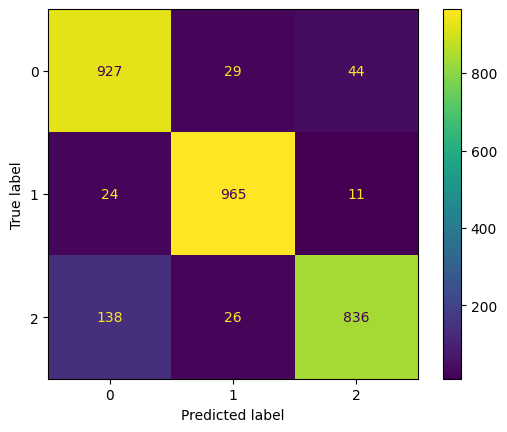

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


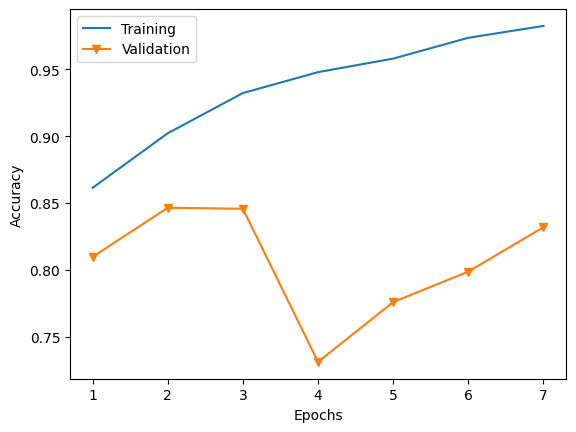

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.8487    0.8920    0.8698      1000
           1     0.9865    0.8790    0.9297      1000
           2     0.7794    0.7560    0.7675      1000
           3     0.7528    0.8190    0.7845      1000

    accuracy                         0.8365      4000
   macro avg     0.8418    0.8365    0.8379      4000
weighted avg     0.8418    0.8365    0.8379      4000



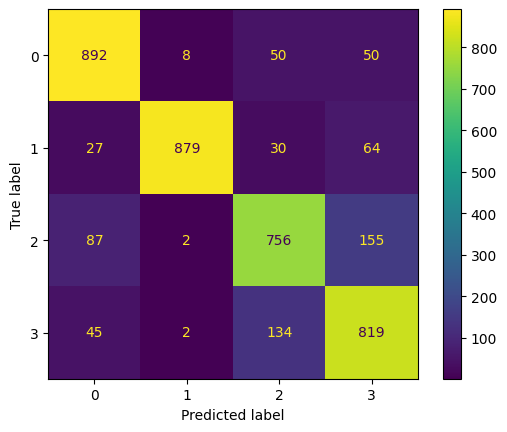

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


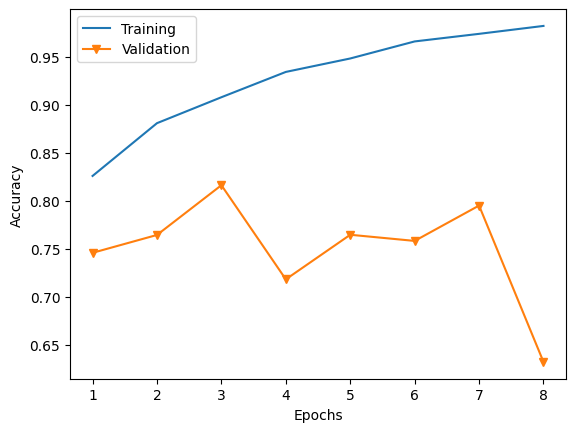

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8292    0.8790    0.8534      1000
           1     0.8885    0.9720    0.9284      1000
           2     0.6881    0.7480    0.7168      1000
           3     0.7949    0.6860    0.7364      1000
           4     0.8036    0.7200    0.7595      1000

    accuracy                         0.8010      5000
   macro avg     0.8009    0.8010    0.7989      5000
weighted avg     0.8009    0.8010    0.7989      5000



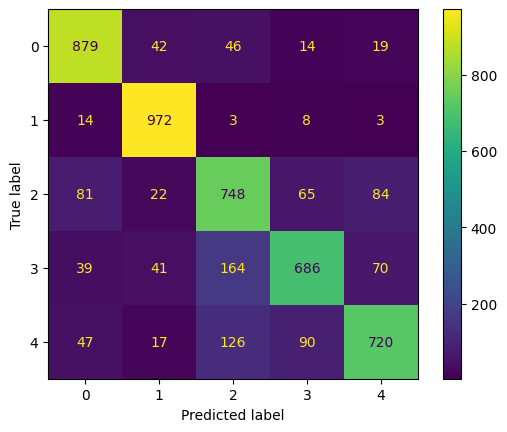

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


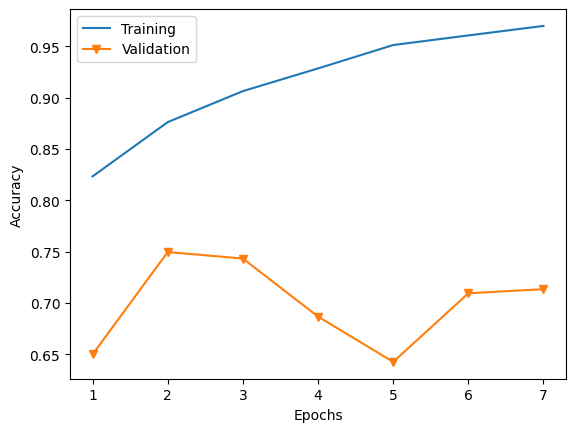

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7761    0.9080    0.8369      1000
           1     0.9290    0.9550    0.9418      1000
           2     0.7652    0.6680    0.7133      1000
           3     0.6878    0.4670    0.5563      1000
           4     0.6479    0.8610    0.7394      1000
           5     0.6862    0.6320    0.6580      1000

    accuracy                         0.7485      6000
   macro avg     0.7487    0.7485    0.7409      6000
weighted avg     0.7487    0.7485    0.7409      6000



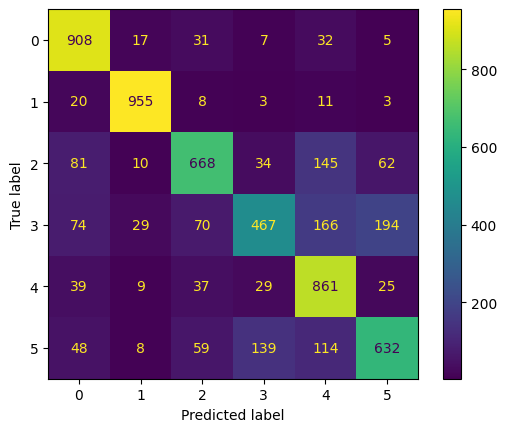

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 5.
Epoch 10: early stopping


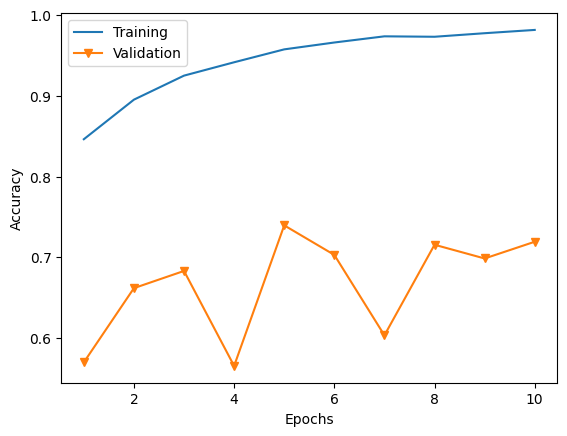

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8988    0.8350    0.8657      1000
           1     0.9311    0.9600    0.9453      1000
           2     0.7891    0.6100    0.6881      1000
           3     0.4552    0.8070    0.5820      1000
           4     0.7724    0.7160    0.7431      1000
           5     0.6632    0.5710    0.6136      1000
           6     0.8470    0.5980    0.7011      1000

    accuracy                         0.7281      7000
   macro avg     0.7653    0.7281    0.7341      7000
weighted avg     0.7653    0.7281    0.7341      7000



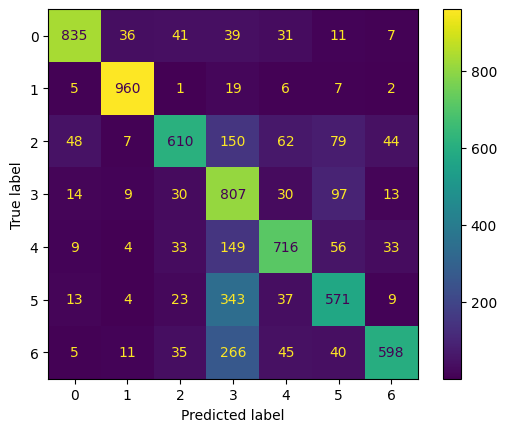

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 3.
Epoch 8: early stopping


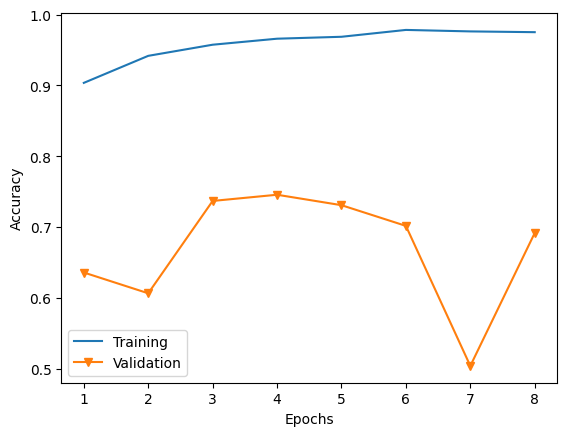

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.7506    0.8970    0.8173      1000
           1     0.9823    0.8890    0.9333      1000
           2     0.7414    0.6450    0.6898      1000
           3     0.5459    0.6660    0.6000      1000
           4     0.6235    0.8080    0.7038      1000
           5     0.8265    0.4050    0.5436      1000
           6     0.8059    0.7930    0.7994      1000
           7     0.7163    0.7450    0.7304      1000

    accuracy                         0.7310      8000
   macro avg     0.7491    0.7310    0.7272      8000
weighted avg     0.7491    0.7310    0.7272      8000



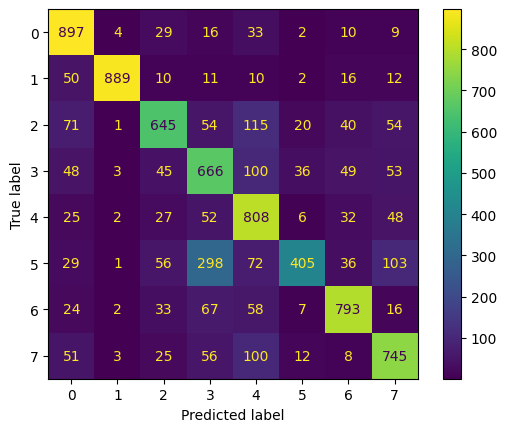

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


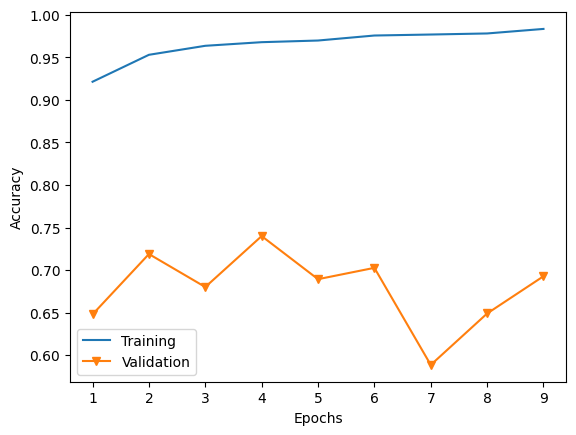

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8388    0.7860    0.8116      1000
           1     0.7883    0.9830    0.8749      1000
           2     0.6988    0.6520    0.6746      1000
           3     0.5865    0.5830    0.5848      1000
           4     0.8036    0.6180    0.6987      1000
           5     0.7291    0.5570    0.6315      1000
           6     0.7414    0.8170    0.7774      1000
           7     0.6403    0.8650    0.7359      1000
           8     0.8682    0.7840    0.8240      1000

    accuracy                         0.7383      9000
   macro avg     0.7439    0.7383    0.7348      9000
weighted avg     0.7439    0.7383    0.7348      9000



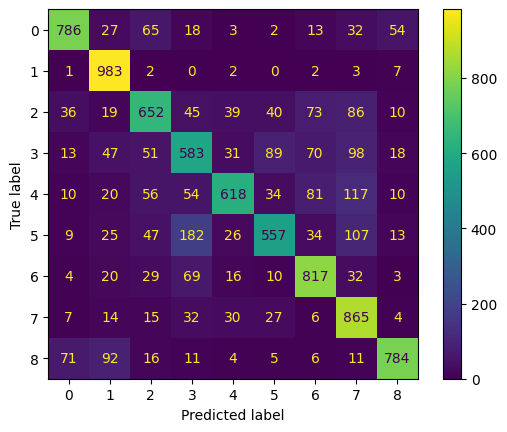

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


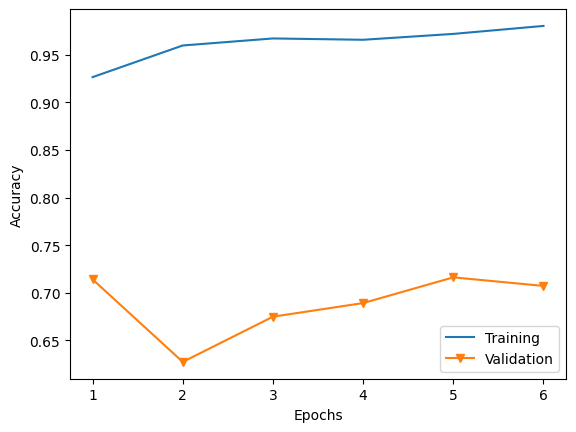

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.8134    0.7760    0.7943      1000
           1     0.7063    0.9260    0.8014      1000
           2     0.8438    0.5240    0.6465      1000
           3     0.7175    0.3200    0.4426      1000
           4     0.7516    0.7080    0.7291      1000
           5     0.6292    0.6890    0.6578      1000
           6     0.5242    0.9440    0.6740      1000
           7     0.6442    0.8490    0.7325      1000
           8     0.8770    0.7770    0.8240      1000
           9     0.8754    0.5480    0.6740      1000

    accuracy                         0.7061     10000
   macro avg     0.7383    0.7061    0.6976     10000
weighted avg     0.7383    0.7061    0.6976     10000



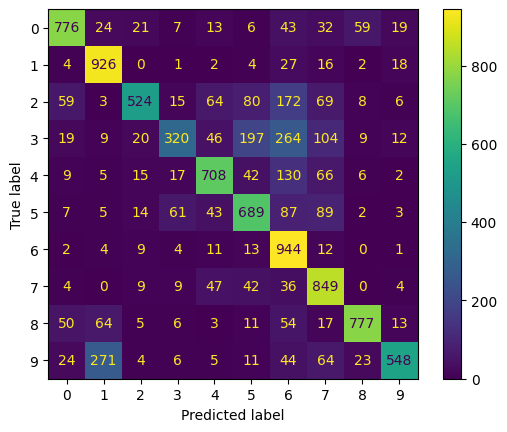

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


---------------------------------------------------------------------------



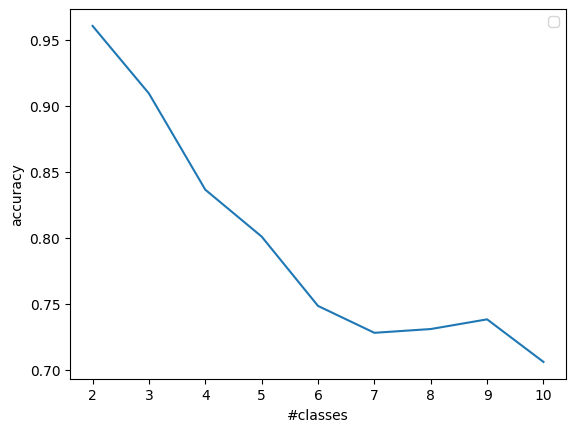

In [5]:
acc_list3 = continually_learn(
    CLASS_NUM, 
    load_cifar10, 
    True,
    False, 
    TUNED_CNN_MODEL_PATH, 
    BATCH_SIZE, 
    EPOCHS
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


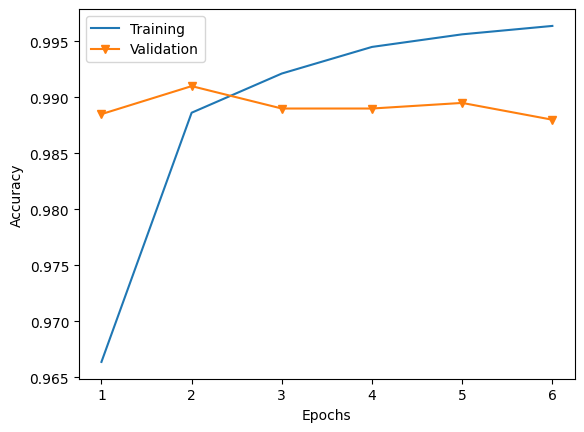

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9890    0.9880    0.9885      1000
           1     0.9880    0.9890    0.9885      1000

    accuracy                         0.9885      2000
   macro avg     0.9885    0.9885    0.9885      2000
weighted avg     0.9885    0.9885    0.9885      2000



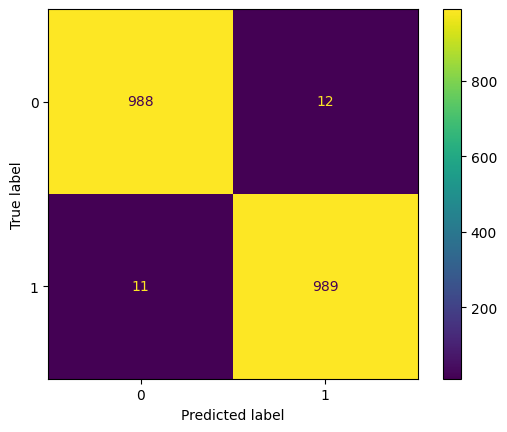

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


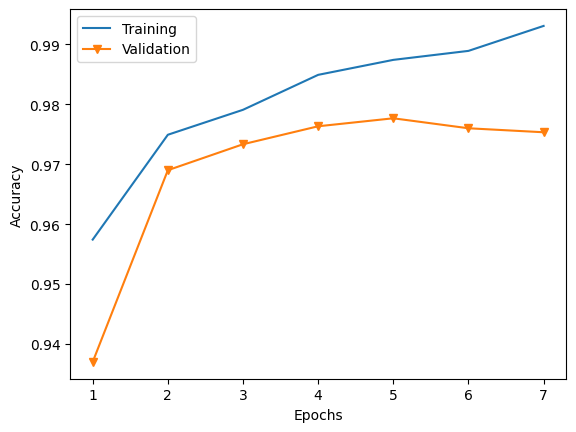

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9703    0.9470    0.9585      1000
           1     0.9919    0.9810    0.9864      1000
           2     0.9536    0.9870    0.9700      1000

    accuracy                         0.9717      3000
   macro avg     0.9719    0.9717    0.9717      3000
weighted avg     0.9719    0.9717    0.9717      3000



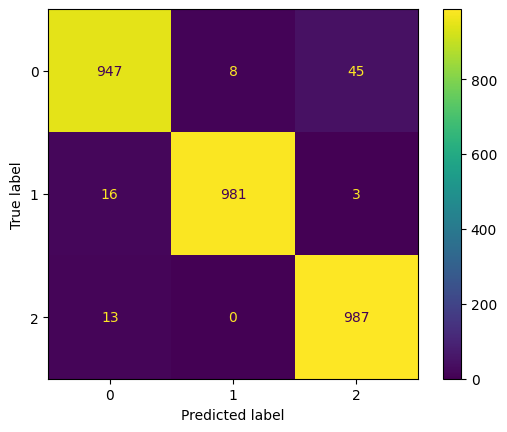

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


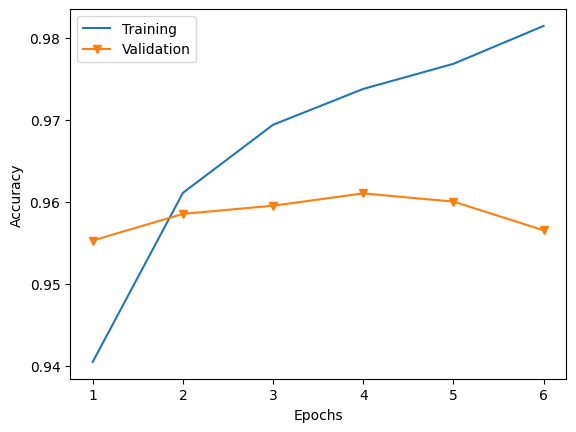

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9669    0.9360    0.9512      1000
           1     0.9829    0.9760    0.9794      1000
           2     0.9656    0.8980    0.9306      1000
           3     0.8738    0.9690    0.9189      1000

    accuracy                         0.9447      4000
   macro avg     0.9473    0.9447    0.9450      4000
weighted avg     0.9473    0.9447    0.9450      4000



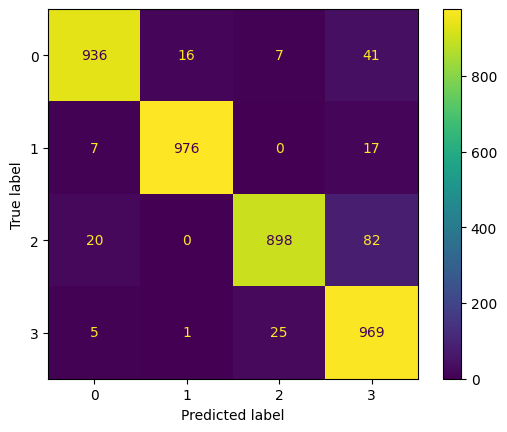

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 4.
Epoch 9: early stopping


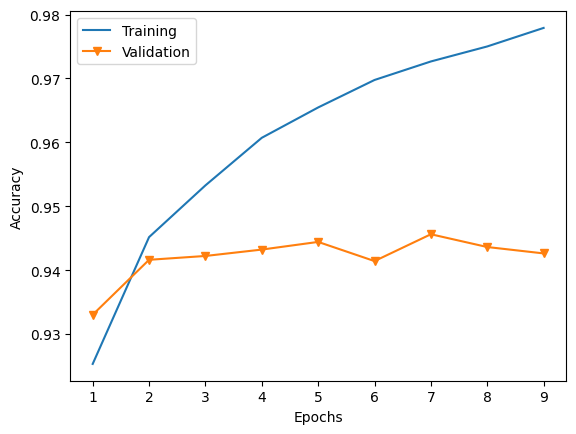

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9634    0.9480    0.9556      1000
           1     0.9831    0.9870    0.9850      1000
           2     0.9367    0.8730    0.9037      1000
           3     0.8799    0.9380    0.9080      1000
           4     0.9142    0.9270    0.9206      1000

    accuracy                         0.9346      5000
   macro avg     0.9355    0.9346    0.9346      5000
weighted avg     0.9355    0.9346    0.9346      5000



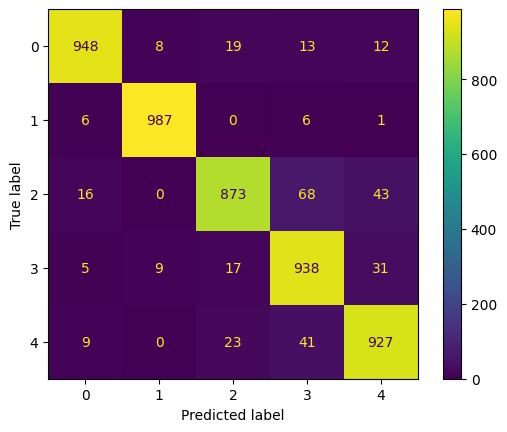

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


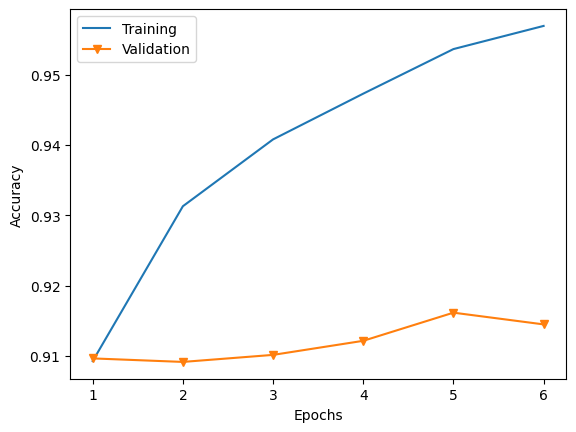

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9556    0.9480    0.9518      1000
           1     0.9880    0.9870    0.9875      1000
           2     0.9191    0.8860    0.9022      1000
           3     0.8254    0.8320    0.8287      1000
           4     0.9002    0.9200    0.9100      1000
           5     0.8512    0.8640    0.8576      1000

    accuracy                         0.9062      6000
   macro avg     0.9066    0.9062    0.9063      6000
weighted avg     0.9066    0.9062    0.9063      6000



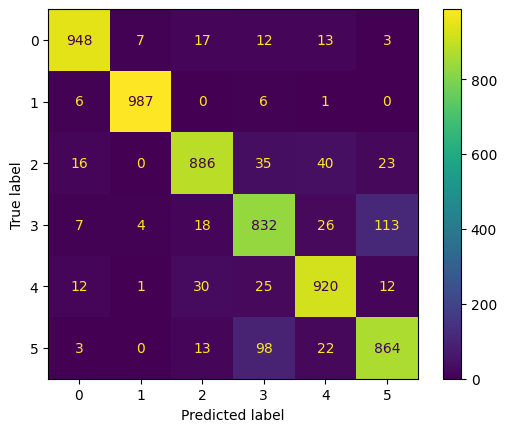

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


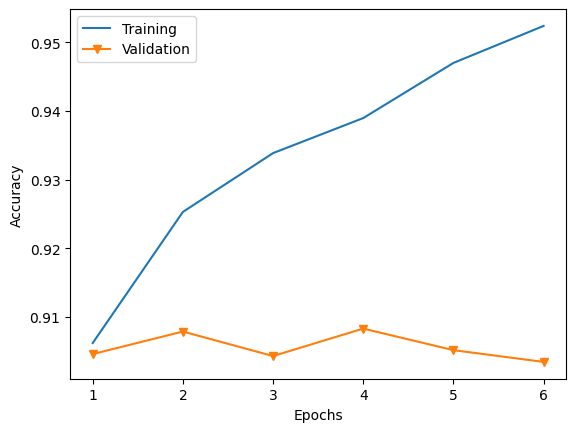

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9515    0.9410    0.9462      1000
           1     0.9859    0.9800    0.9829      1000
           2     0.9126    0.8560    0.8834      1000
           3     0.7982    0.7950    0.7966      1000
           4     0.8906    0.9120    0.9012      1000
           5     0.8610    0.8610    0.8610      1000
           6     0.8735    0.9250    0.8985      1000

    accuracy                         0.8957      7000
   macro avg     0.8962    0.8957    0.8957      7000
weighted avg     0.8962    0.8957    0.8957      7000



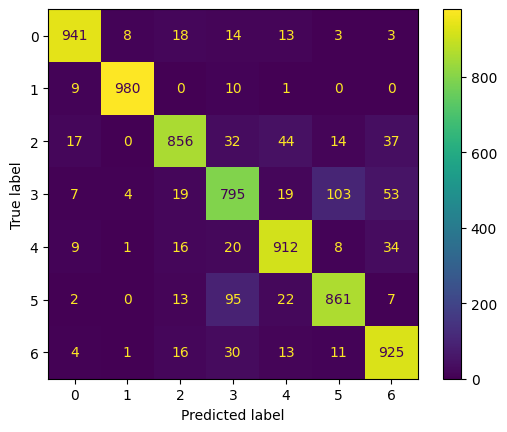

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


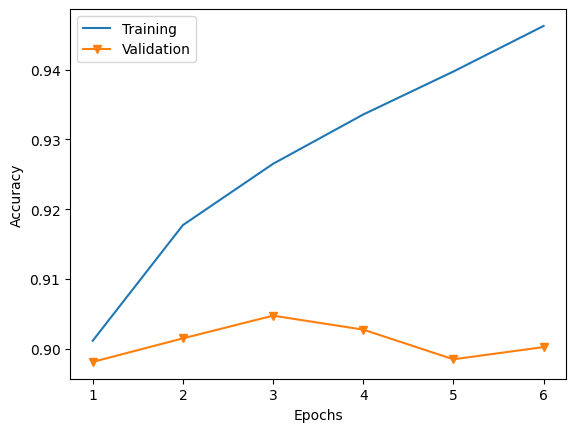

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9412    0.9440    0.9426      1000
           1     0.9908    0.9660    0.9782      1000
           2     0.9101    0.8500    0.8790      1000
           3     0.7783    0.8040    0.7909      1000
           4     0.8673    0.8690    0.8681      1000
           5     0.8571    0.8580    0.8576      1000
           6     0.8999    0.9170    0.9084      1000
           7     0.8848    0.9140    0.8992      1000

    accuracy                         0.8902      8000
   macro avg     0.8912    0.8902    0.8905      8000
weighted avg     0.8912    0.8902    0.8905      8000



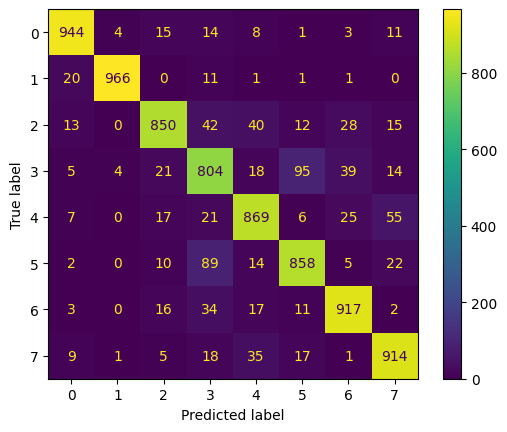

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


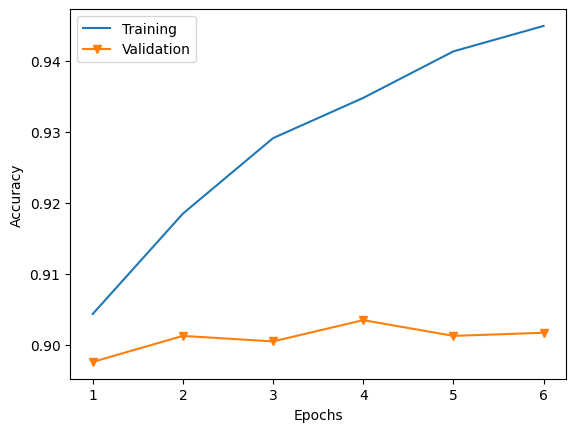

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9346    0.8720    0.9022      1000
           1     0.9789    0.9760    0.9775      1000
           2     0.9085    0.8540    0.8804      1000
           3     0.7583    0.8440    0.7989      1000
           4     0.8481    0.8930    0.8699      1000
           5     0.8741    0.8330    0.8530      1000
           6     0.9223    0.8900    0.9059      1000
           7     0.9160    0.9050    0.9105      1000
           8     0.9064    0.9590    0.9320      1000

    accuracy                         0.8918      9000
   macro avg     0.8941    0.8918    0.8922      9000
weighted avg     0.8941    0.8918    0.8922      9000



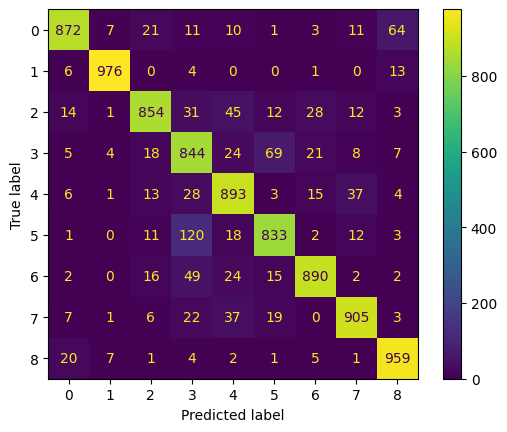

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


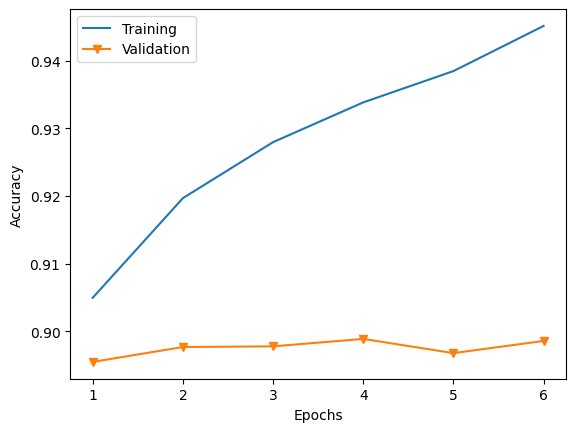

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9113    0.9040    0.9076      1000
           1     0.9522    0.9170    0.9343      1000
           2     0.9164    0.8440    0.8787      1000
           3     0.8024    0.8120    0.8072      1000
           4     0.8399    0.8970    0.8675      1000
           5     0.8656    0.8500    0.8577      1000
           6     0.9094    0.9130    0.9112      1000
           7     0.9074    0.9020    0.9047      1000
           8     0.9176    0.9580    0.9374      1000
           9     0.9039    0.9220    0.9129      1000

    accuracy                         0.8919     10000
   macro avg     0.8926    0.8919    0.8919     10000
weighted avg     0.8926    0.8919    0.8919     10000



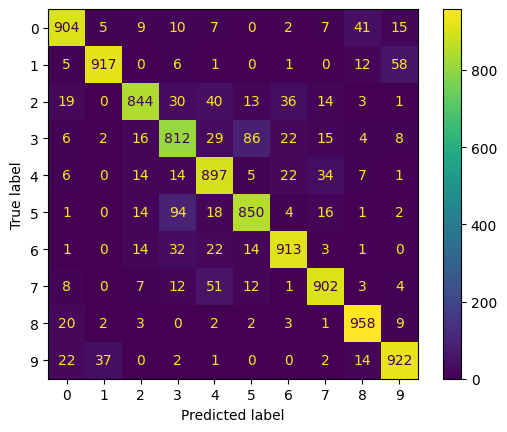

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


---------------------------------------------------------------------------



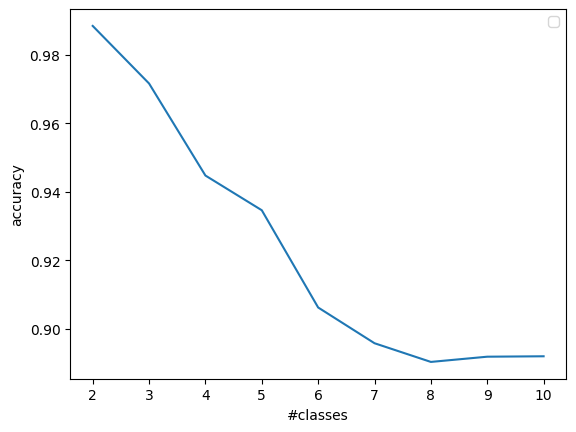

In [6]:
acc_list4 = continually_learn(
    CLASS_NUM, 
    load_cifar10, 
    True,
    False, 
    TUNED_DNN_MODEL_PATH, 
    BATCH_SIZE, 
    EPOCHS
)

## Continually adding classes to the same model without the previous data

### CNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 14.
Epoch 19: early stopping


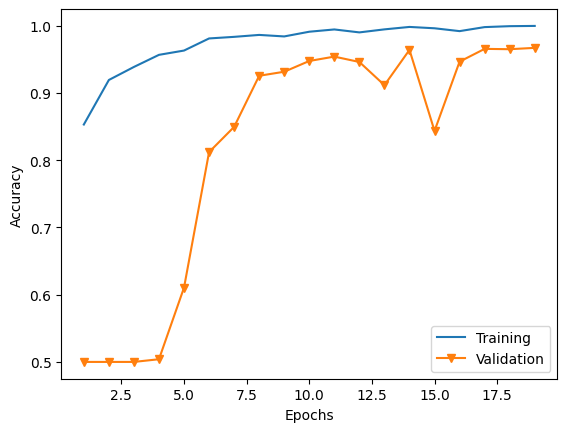

63/63 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.9567    0.9720    0.9643      1000
           1     0.9715    0.9560    0.9637      1000

    accuracy                         0.9640      2000
   macro avg     0.9641    0.9640    0.9640      2000
weighted avg     0.9641    0.9640    0.9640      2000



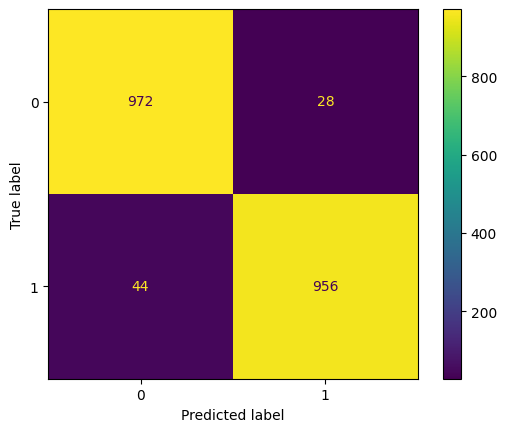

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


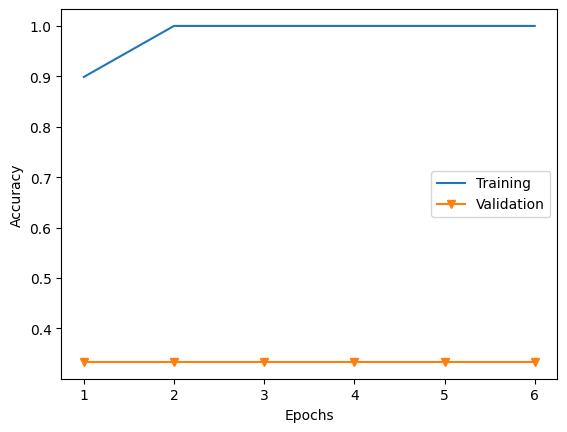

94/94 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.3333    1.0000    0.5000      1000

    accuracy                         0.3333      3000
   macro avg     0.1111    0.3333    0.1667      3000
weighted avg     0.1111    0.3333    0.1667      3000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


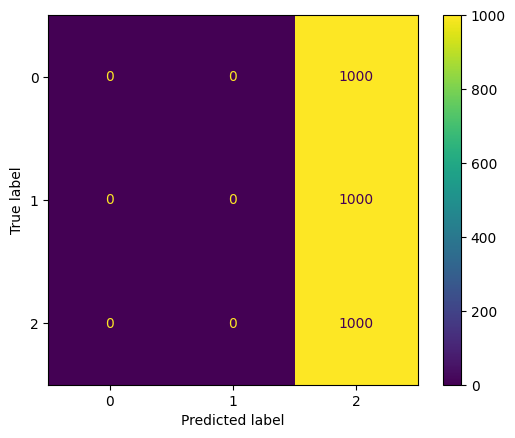

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


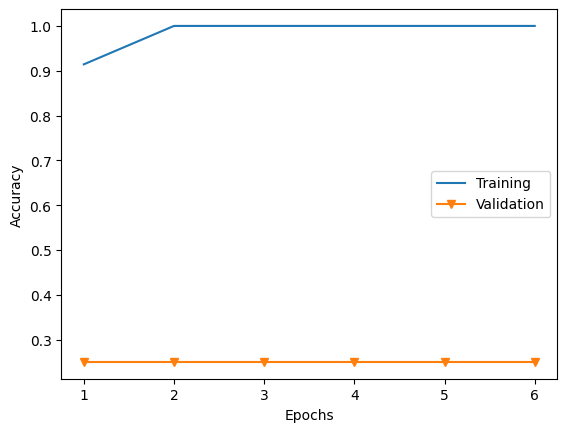

125/125 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.2500    1.0000    0.4000      1000

    accuracy                         0.2500      4000
   macro avg     0.0625    0.2500    0.1000      4000
weighted avg     0.0625    0.2500    0.1000      4000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


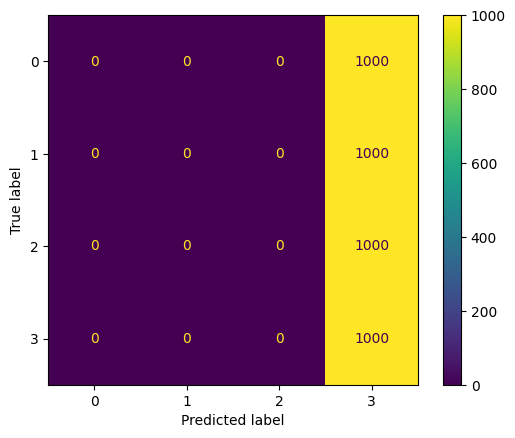

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


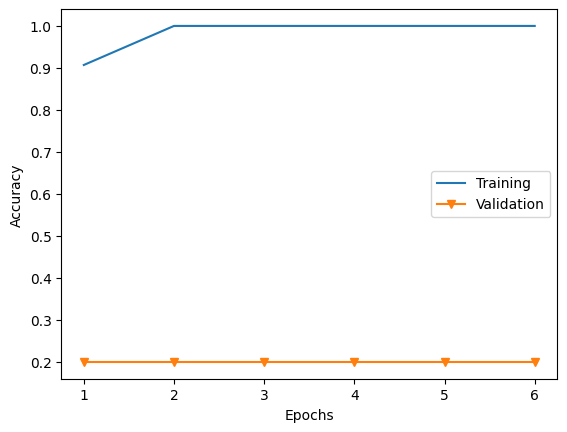

157/157 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.2000    1.0000    0.3333      1000

    accuracy                         0.2000      5000
   macro avg     0.0400    0.2000    0.0667      5000
weighted avg     0.0400    0.2000    0.0667      5000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


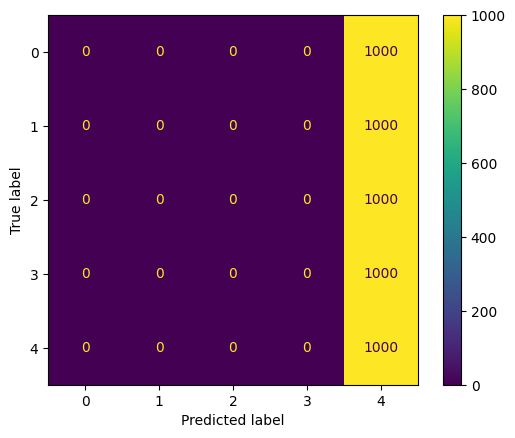

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


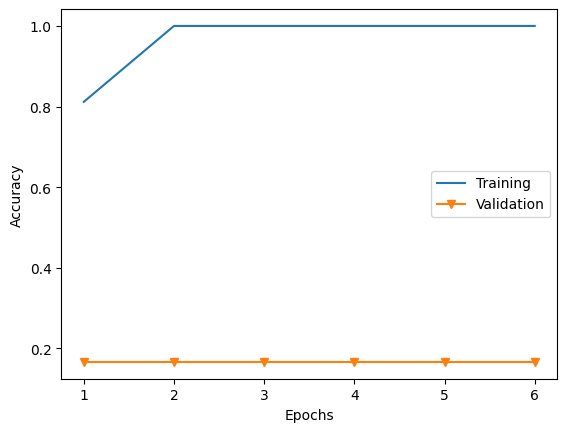

188/188 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.1667    1.0000    0.2857      1000

    accuracy                         0.1667      6000
   macro avg     0.0278    0.1667    0.0476      6000
weighted avg     0.0278    0.1667    0.0476      6000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


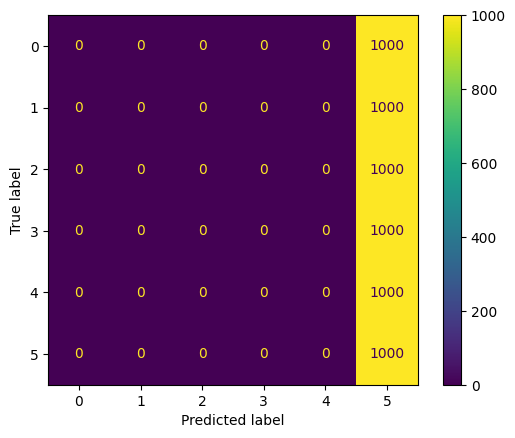

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


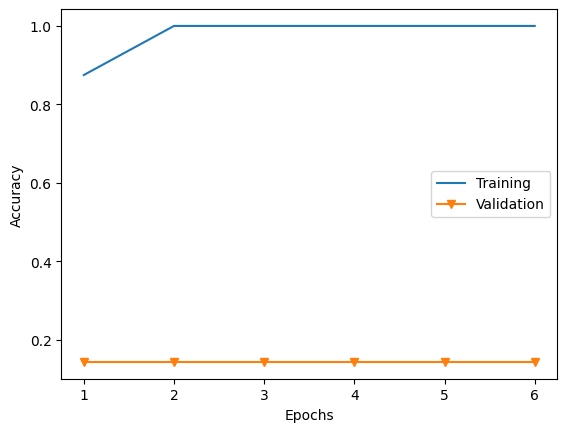

219/219 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.1429    1.0000    0.2500      1000

    accuracy                         0.1429      7000
   macro avg     0.0204    0.1429    0.0357      7000
weighted avg     0.0204    0.1429    0.0357      7000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


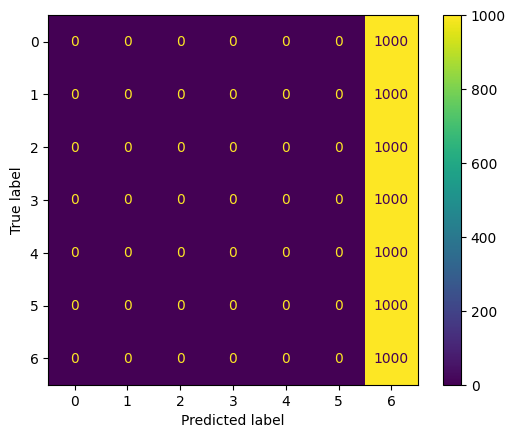

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


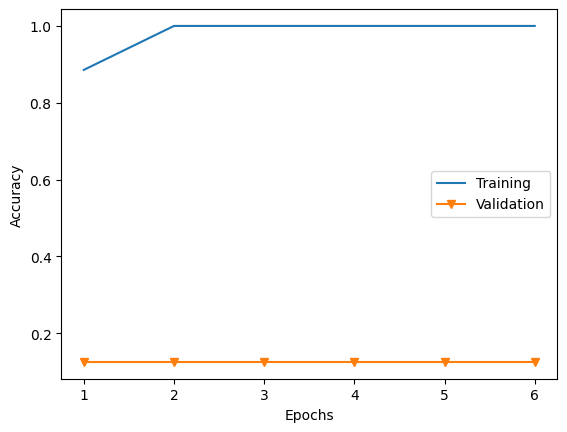

250/250 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.1250    1.0000    0.2222      1000

    accuracy                         0.1250      8000
   macro avg     0.0156    0.1250    0.0278      8000
weighted avg     0.0156    0.1250    0.0278      8000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


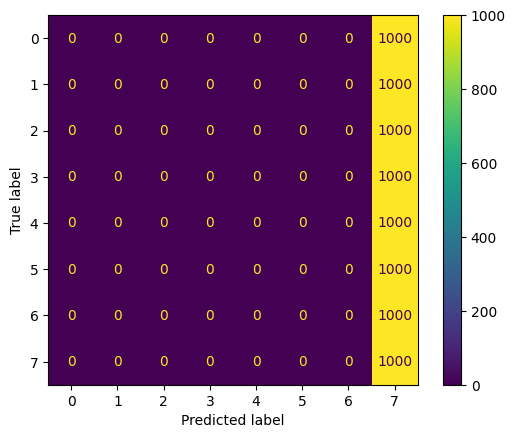

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


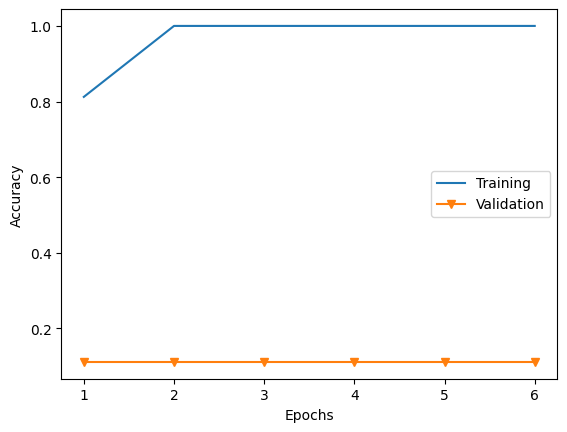

282/282 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.0000    0.0000    0.0000      1000
           8     0.1111    1.0000    0.2000      1000

    accuracy                         0.1111      9000
   macro avg     0.0123    0.1111    0.0222      9000
weighted avg     0.0123    0.1111    0.0222      9000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


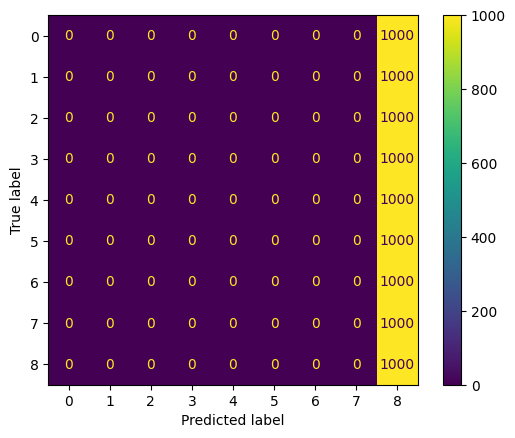

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


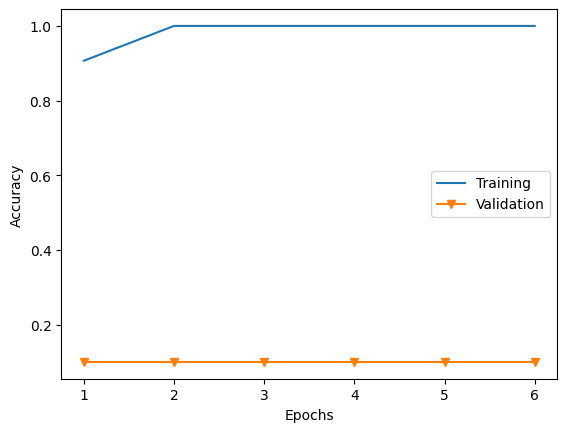

313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.0000    0.0000    0.0000      1000
           7     0.0000    0.0000    0.0000      1000
           8     0.0000    0.0000    0.0000      1000
           9     0.1000    1.0000    0.1818      1000

    accuracy                         0.1000     10000
   macro avg     0.0100    0.1000    0.0182     10000
weighted avg     0.0100    0.1000    0.0182     10000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


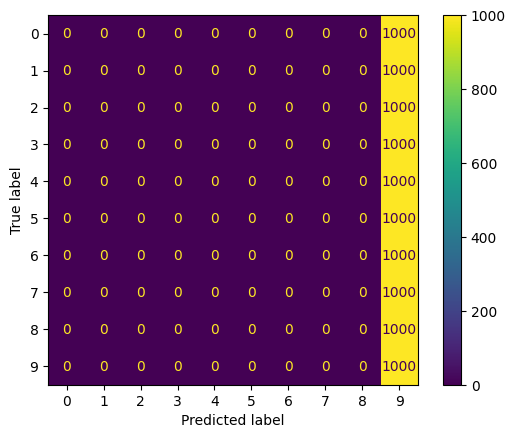

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


---------------------------------------------------------------------------



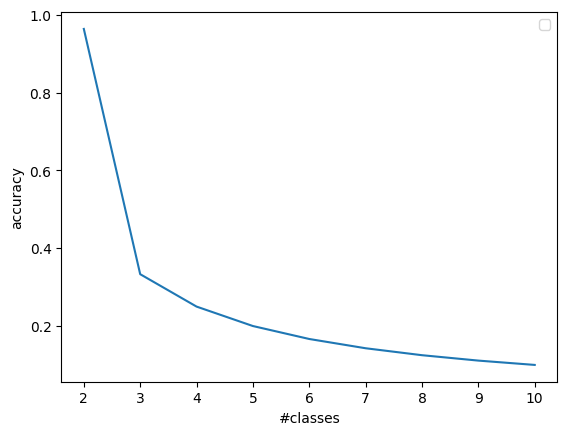

In [7]:
acc_list5 = continually_learn(
    CLASS_NUM, 
    load_cifar10, 
    True, 
    True,
    TUNED_CNN_MODEL_PATH, 
    BATCH_SIZE, 
    EPOCHS
)

### DNN Model

--------------------------------------------------------------------------- Classes: [0, 1]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


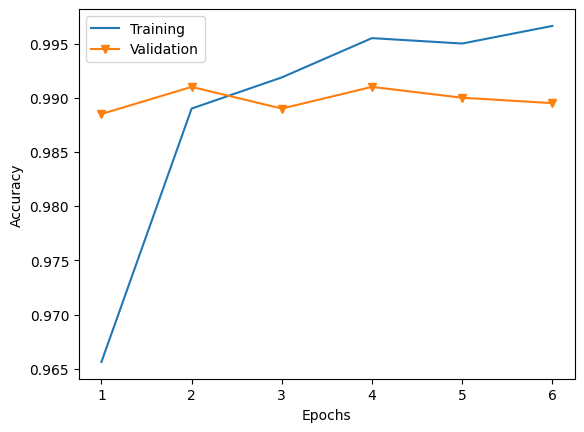

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.9909    0.9770    0.9839      1000
           1     0.9773    0.9910    0.9841      1000

    accuracy                         0.9840      2000
   macro avg     0.9841    0.9840    0.9840      2000
weighted avg     0.9841    0.9840    0.9840      2000



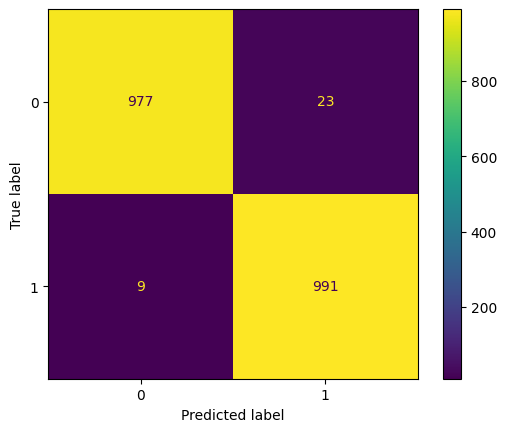

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


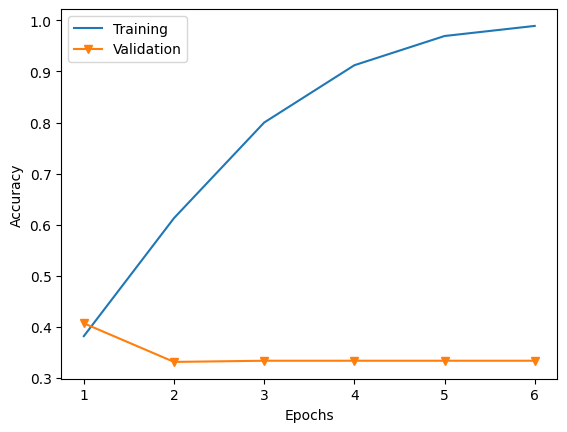

94/94 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.6751    0.1600    0.2587      1000
           1     0.2209    0.1610    0.1862      1000
           2     0.4410    0.8970    0.5913      1000

    accuracy                         0.4060      3000
   macro avg     0.4457    0.4060    0.3454      3000
weighted avg     0.4457    0.4060    0.3454      3000



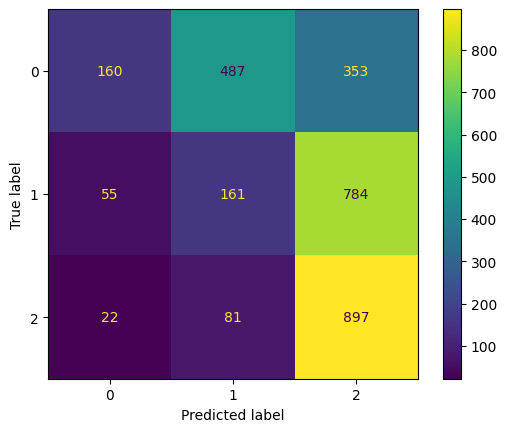

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


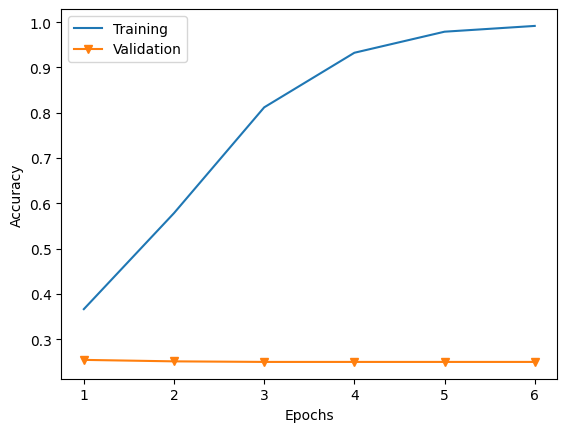

125/125 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.4054    0.0300    0.0559      1000
           1     0.0227    0.0020    0.0037      1000
           2     0.3323    0.6200    0.4327      1000
           3     0.2104    0.4150    0.2793      1000

    accuracy                         0.2667      4000
   macro avg     0.2427    0.2667    0.1929      4000
weighted avg     0.2427    0.2667    0.1929      4000



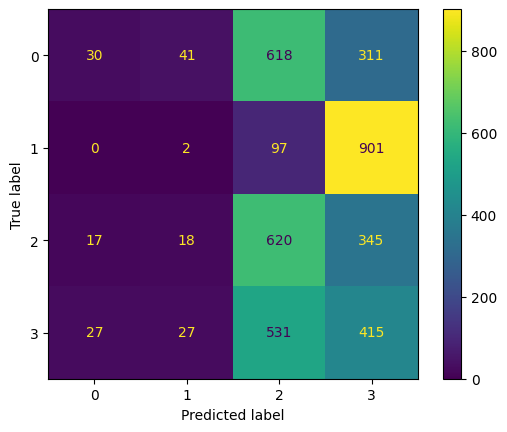

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


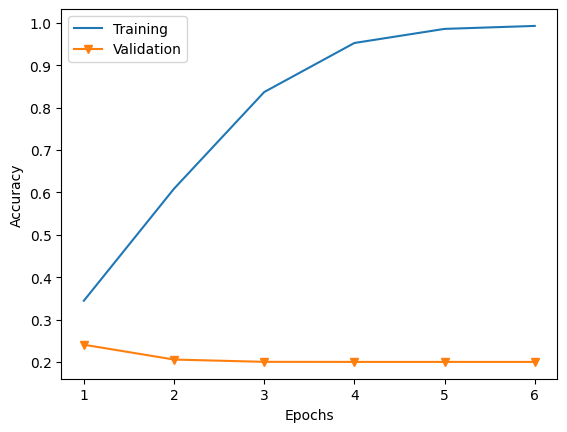

157/157 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.0357    0.0010    0.0019      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.3406    0.2640    0.2975      1000
           3     0.3912    0.2210    0.2824      1000
           4     0.2028    0.7350    0.3179      1000

    accuracy                         0.2442      5000
   macro avg     0.1941    0.2442    0.1799      5000
weighted avg     0.1941    0.2442    0.1799      5000



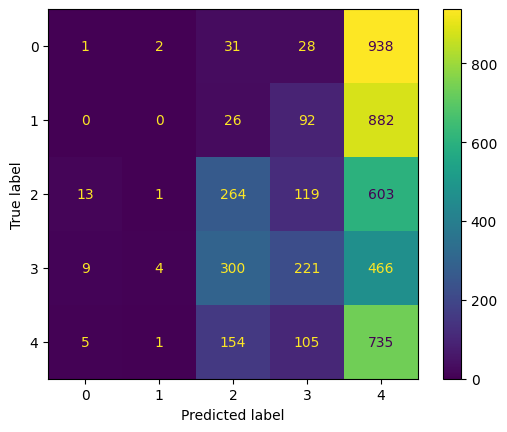

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


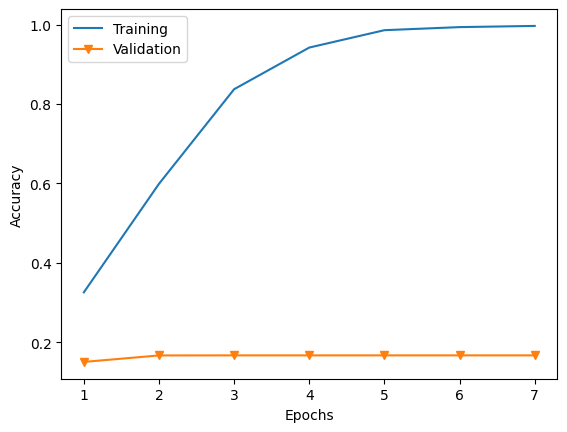

188/188 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.5000    0.0010    0.0020      1000
           3     0.1667    0.0010    0.0020      1000
           4     0.0071    0.0030    0.0042      1000
           5     0.1785    0.9940    0.3026      1000

    accuracy                         0.1665      6000
   macro avg     0.1420    0.1665    0.0518      6000
weighted avg     0.1420    0.1665    0.0518      6000



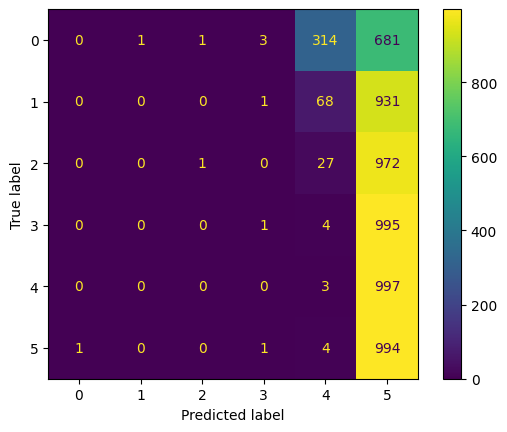

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


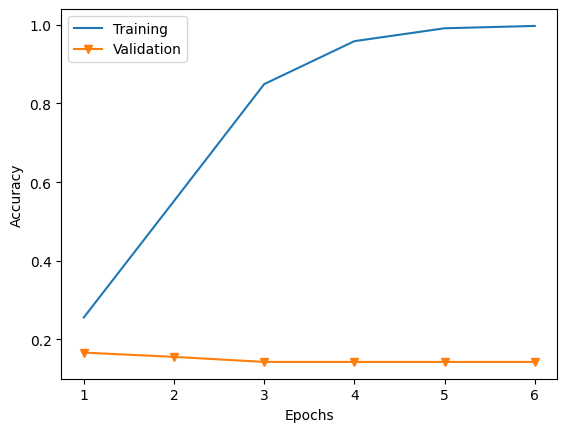

219/219 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.5000    0.0010    0.0020      1000
           3     0.3125    0.0050    0.0098      1000
           4     0.0101    0.0030    0.0046      1000
           5     0.1461    0.6320    0.2373      1000
           6     0.2306    0.5440    0.3239      1000

    accuracy                         0.1693      7000
   macro avg     0.1713    0.1693    0.0825      7000
weighted avg     0.1713    0.1693    0.0825      7000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


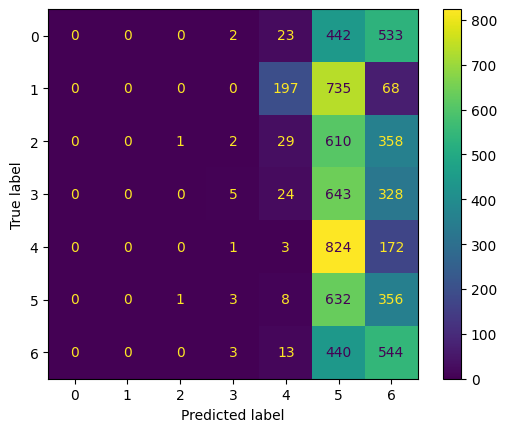

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
Restoring model weights from the end of the best epoch: 2.
Epoch 7: early stopping


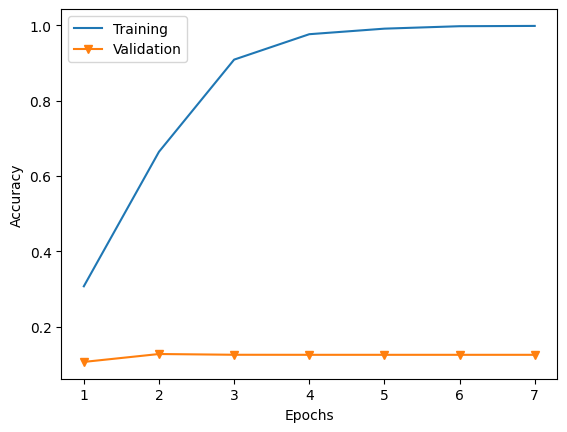

250/250 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0217    0.0010    0.0019      1000
           6     0.1417    0.0170    0.0304      1000
           7     0.1264    0.9900    0.2242      1000

    accuracy                         0.1260      8000
   macro avg     0.0362    0.1260    0.0321      8000
weighted avg     0.0362    0.1260    0.0321      8000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


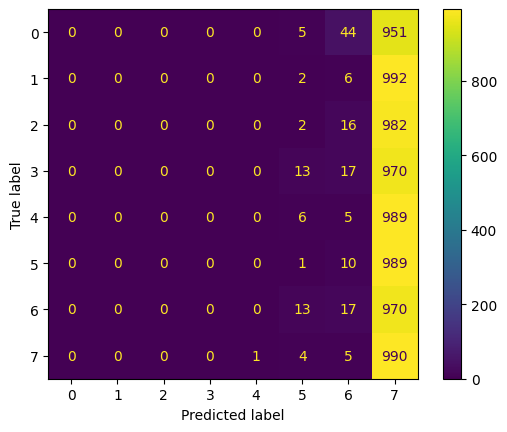

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


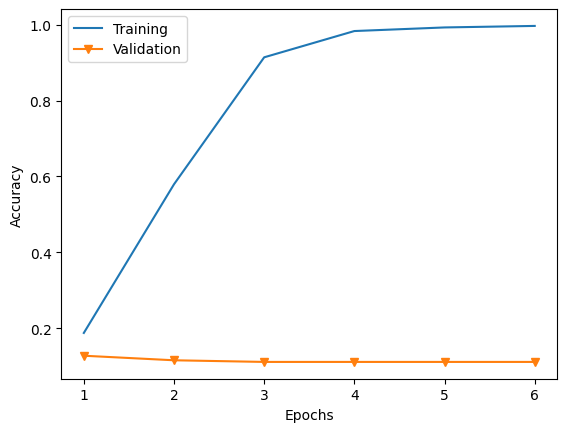

282/282 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.2353    0.0040    0.0079      1000
           6     0.0556    0.0010    0.0020      1000
           7     0.1439    0.7750    0.2428      1000
           8     0.1017    0.3640    0.1590      1000

    accuracy                         0.1271      9000
   macro avg     0.0596    0.1271    0.0457      9000
weighted avg     0.0596    0.1271    0.0457      9000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


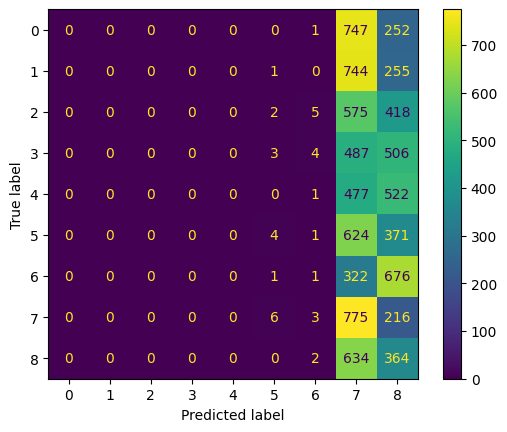

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Restoring model weights from the end of the best epoch: 1.
Epoch 6: early stopping


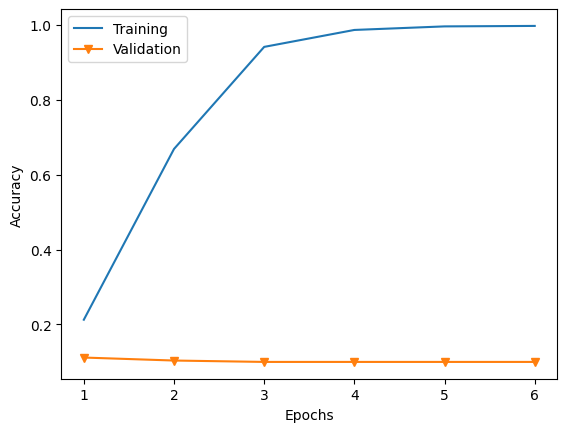

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1000
           1     0.0000    0.0000    0.0000      1000
           2     0.0000    0.0000    0.0000      1000
           3     0.0000    0.0000    0.0000      1000
           4     0.0000    0.0000    0.0000      1000
           5     0.0000    0.0000    0.0000      1000
           6     0.1250    0.0010    0.0020      1000
           7     0.1643    0.3540    0.2244      1000
           8     0.0921    0.1640    0.1179      1000
           9     0.1019    0.6170    0.1750      1000

    accuracy                         0.1136     10000
   macro avg     0.0483    0.1136    0.0519     10000
weighted avg     0.0483    0.1136    0.0519     10000



c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hosein\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


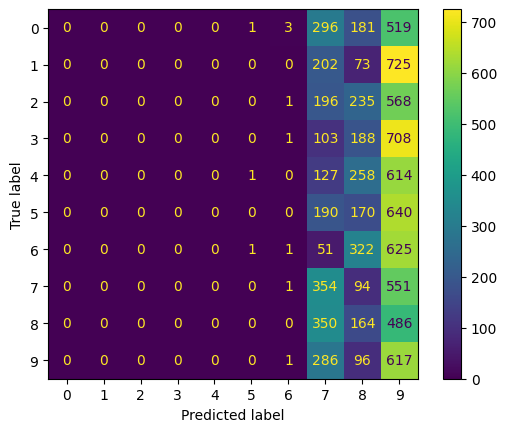

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


---------------------------------------------------------------------------



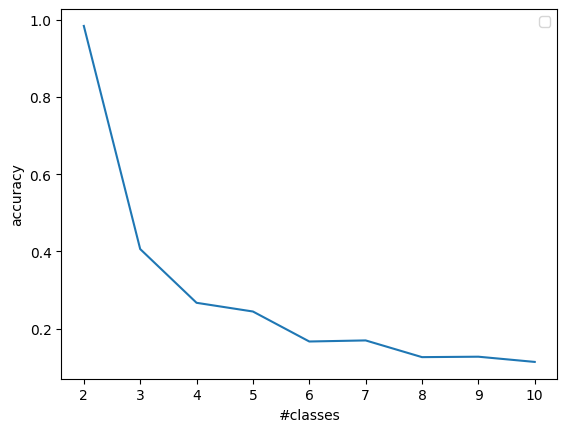

In [8]:
acc_list6 = continually_learn(
    CLASS_NUM, 
    load_cifar10, 
    True, 
    True, 
    TUNED_DNN_MODEL_PATH, 
    BATCH_SIZE, 
    EPOCHS
)

## Conclusion

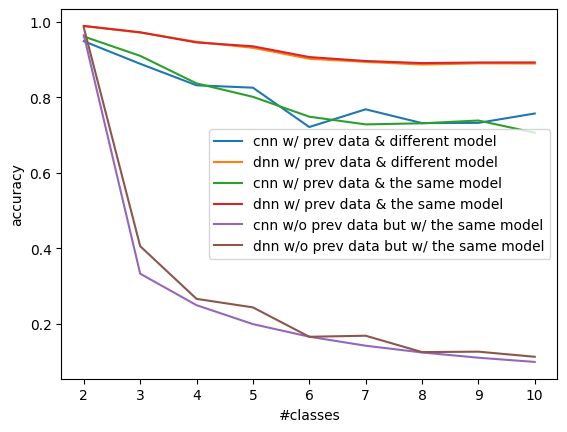

In [9]:
CL_plot(CLASS_NUM, 
    [
    (acc_list1, "cnn w/ prev data & different model"), 
    (acc_list2, "dnn w/ prev data & different model"), 
    (acc_list3, "cnn w/ prev data & the same model"), 
    (acc_list4, "dnn w/ prev data & the same model"), 
    (acc_list5, "cnn w/o prev data but w/ the same model"), 
    (acc_list6, "dnn w/o prev data but w/ the same model"), 
    ]
)